In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Compatibility patch for SHAP 0.39 with NumPy>=1.24
if not hasattr(np, 'bool'):
    np.bool = bool

import shap
import warnings

# Check SHAP version
print(f"SHAP version: {shap.__version__}")

warnings.filterwarnings('ignore')

# Global font setup: prioritize Times New Roman for titles/labels (CJK fallback enabled)
plt.rcParams['font.family'] = [
    'Times New Roman',
    'Microsoft YaHei', 'SimHei',
    'DejaVu Sans'
 ]
plt.rcParams['mathtext.fontset'] = 'stix'  # Make CO$_2$ and other math text closer to Times style
plt.rcParams['axes.unicode_minus'] = False  # Use ASCII minus for better compatibility

print("✓ All libraries imported successfully (including SHAP)")

C:\Users\Wu Jinrui\AppData\Local\Temp\ipykernel_8312\2995602251.py:10: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'bool'):


SHAP version: 0.39.0
✓ All libraries imported successfully (including SHAP)


d:\Anaconda3\envs\LSTM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Data Loading and Timestamp Parsing

In [2]:
# Load data
try:
    df = pd.read_excel('CO2_capacity.xlsx', engine='openpyxl')
    print(f"✓ Data loaded successfully, shape: {df.shape}")
except Exception as e:
    raise RuntimeError(f"Read failed: {e}")

# Show first rows
print(f"\nFirst 5 rows:")
print(df.head())

# Identify columns
time_col = df.columns[0]  # First column is timestamp
target_col = df.columns[-1]  # Last column is target (CO2 capacity)

print(f"\nColumn role definition:")
print(f"  • Time column: {time_col}")
print(f"  • Target column: {target_col}")
print(f"  • Data frequency: 1 minute")
print(f"  • Total records: {len(df)}")

✓ Data loaded successfully, shape: (7200, 59)

First 5 rows:
                 Date      PI-2       TI-2         FI-2      PI-3       TI-3  \
0 2020-01-20 00:00:00 -0.053126  34.736652  1543.938721  0.052434  45.023132   
1 2020-01-20 00:01:00 -0.053289  34.732132  1541.767578  0.052564  45.045799   
2 2020-01-20 00:02:00 -0.053386  34.761639  1545.614746  0.052390  45.088932   
3 2020-01-20 00:03:00 -0.053370  34.731682  1544.225952  0.052236  45.071358   
4 2020-01-20 00:04:00 -0.053144  34.718353  1540.848267  0.052370  45.036755   

       O2-3      TI-32      TI-33      TI-34  ...        FI-16      TI-16  \
0  5.170577  37.777477  50.215652  61.217957  ...  9634.049805  34.619560   
1  5.139907  37.836792  50.203251  61.241829  ...  9661.376953  34.598999   
2  5.078373  37.840168  50.180534  61.217957  ...  9662.280273  34.551292   
3  4.915955  37.849812  50.215652  61.322845  ...  9656.855469  34.583843   
4  5.042109  37.914433  50.229359  61.233147  ...  9641.303711  34.584705

## Step 2: Feature Selection and Chronological Split

In [3]:
# Selected 12 features (from correlation analysis)

selected_features = ['TI-34', 'TI-33', 'FI-30', 'FI-38', 'TI-4', 'TI-19', 'TI-12', 'TI-22', 'TI-24','TI-28', 'Level Reboiler']

# Validate whether features exist
missing_features = [f for f in selected_features if f not in df.columns]
if missing_features:
    print(f"⚠ Warning: the following features are missing: {missing_features}")
    print(f"Actual columns: {list(df.columns)}")
    selected_features = [f for f in selected_features if f in df.columns]
    print(f"Using available features: {selected_features}")

print(f"\nSelected features (total {len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

# Extract features and target
X = df[selected_features].copy()
y = df[target_col].copy()

# Handle missing values (median imputation)
X.fillna(X.median(), inplace=True)
y.fillna(y.median(), inplace=True)

print(f"\nTarget variable statistics:")
print(f"  • Minimum: {y.min():.6f}")
print(f"  • Maximum: {y.max():.6f}")
print(f"  • Mean: {y.mean():.6f}")
print(f"  • Standard deviation: {y.std():.6f}")

# Chronological split: first 80% for training, last 20% for testing
split_idx = int(len(df) * 0.8)

X_train_raw = X.iloc[:split_idx].reset_index(drop=True)
X_test_raw = X.iloc[split_idx:].reset_index(drop=True)
y_train_raw = y.iloc[:split_idx].reset_index(drop=True)
y_test_raw = y.iloc[split_idx:].reset_index(drop=True)

print(f"\nChronological split result:")
print(f"  • Training data: {len(X_train_raw)} rows (first 80%)")
print(f"  • Test data: {len(X_test_raw)} rows (last 20%)")


Selected features (total 11):
  1. TI-34
  2. TI-33
  3. FI-30
  4. FI-38
  5. TI-4
  6. TI-19
  7. TI-12
  8. TI-22
  9. TI-24
  10. TI-28
  11. Level Reboiler

Target variable statistics:
  • Minimum: 0.582062
  • Maximum: 0.948009
  • Mean: 0.864631
  • Standard deviation: 0.045872

Chronological split result:
  • Training data: 5760 rows (first 80%)
  • Test data: 1440 rows (last 20%)


## Step 3: Use Raw Data Directly (Random Forest Is Insensitive to Feature Scaling)

In [4]:
# Random Forest is tree-based and insensitive to feature scaling, so raw values are used directly
print("✓ Using raw data (no standardization)")
print(f"\nTraining feature statistics (raw values):")
print(f"  • Mean: {X_train_raw.mean().values}")
print(f"  • Variance: {X_train_raw.var().values}")
print(f"  • Minimum: {X_train_raw.min().values}")
print(f"  • Maximum: {X_train_raw.max().values}")

✓ Using raw data (no standardization)

Training feature statistics (raw values):
  • Mean: [ 63.01994574  51.6572464  281.50556714 373.27202882  46.57372443
  47.50509909  43.18887455  63.33777058  41.68796348  90.03880434
  70.2182511 ]
  • Variance: [5.58310455e+00 3.45825570e+00 4.30075976e+02 1.28032381e+03
 5.54920509e+00 4.53039475e+00 1.14720665e+01 7.99550261e+00
 2.43238441e+00 2.96248279e+00 7.93687253e-01]
  • Minimum: [5.17452812e+01 4.53763733e+01 9.26589279e+01 6.99569806e-02
 3.56008873e+01 3.52613869e+01 3.90961189e+01 4.29024811e+01
 3.76834412e+01 7.49711609e+01 6.86522903e+01]
  • Maximum: [ 68.80599976  55.41588593 437.49478149 473.13320923  55.4248085
  62.66413498  55.8631897   70.11131287  47.23034668  96.08318329
  74.99525452]


## Step 4: Build Sliding-Window Data

**Rule:** Use feature values from the previous 10 time steps (10 minutes) as input to predict the target value at the next time step (the 11th minute).

In [5]:
def create_sliding_windows(X, y, window_size=10):
    """
    Build sliding-window data.

    Parameters:
      X: Feature data (n_samples, n_features)
      y: Target data (n_samples,)
      window_size: Window size (default: 10)

    Returns:
      X_windows: Windowed features (n_windows, window_size * n_features)
      y_windows: Windowed targets (n_windows,)
    """
    X_windows = []
    y_windows = []

    for i in range(len(X) - window_size):
        # Take features from i to i+window_size-1 and flatten into one row
        window = X.iloc[i:i+window_size].values.flatten()
        X_windows.append(window)

        # Target is the value at i+window_size
        y_windows.append(y.iloc[i+window_size])

    return np.array(X_windows), np.array(y_windows)

# Build training windows
X_train_windows, y_train_windows = create_sliding_windows(X_train_raw, y_train_raw, window_size=10)

# Build test windows
X_test_windows, y_test_windows = create_sliding_windows(X_test_raw, y_test_raw, window_size=10)

print(f"✓ Sliding windows built successfully")
print(f"\nTraining data:")
print(f"  • Number of samples: {X_train_windows.shape[0]}")
print(f"  • Feature dimension: {X_train_windows.shape[1]} (10 minutes × {len(selected_features)} features)")
print(f"\nTest data:")
print(f"  • Number of samples: {X_test_windows.shape[0]}")
print(f"  • Feature dimension: {X_test_windows.shape[1]}")

print(f"\nSample preview (first training sample):")
print(f"  Input shape: {X_train_windows[0].shape}")
print(f"  Input (first 20 values): {X_train_windows[0][:20]}")
print(f"  Target value: {y_train_windows[0]}")

✓ Sliding windows built successfully

Training data:
  • Number of samples: 5750
  • Feature dimension: 110 (10 minutes × 11 features)

Test data:
  • Number of samples: 1430
  • Feature dimension: 110

Sample preview (first training sample):
  Input shape: (110,)
  Input (first 20 values): [ 61.21795654  50.21565247 281.14794922 366.61743164  45.44509125
  46.43609619  41.40271378  61.92232895  40.36348724  89.95625305
  70.96716309  61.24182892  50.20325089 277.5836792  368.57546997
  45.44147491  46.3895607   41.40874481  61.90945435  40.37795639]
  Target value: 0.846168723536747


## Step 5: Random Forest Model Training

In [6]:
# Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=400,           # Number of trees
    max_depth=35,               # Maximum depth
    min_samples_split=40,       # Minimum samples required to split
    min_samples_leaf=10,        # Minimum samples in a leaf node
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_windows, y_train_windows)

print(f"✓ Model training completed")
print(f"\nModel configuration:")
print(f"  • Model type: RandomForestRegressor")
print(f"  • Number of trees: {rf_model.n_estimators}")
print(f"  • Maximum depth: {rf_model.max_depth}")
print(f"  • Min samples split: {rf_model.min_samples_split}")
print(f"  • Min samples leaf: {rf_model.min_samples_leaf}")

# Training-set performance
y_train_pred = rf_model.predict(X_train_windows)
train_r2 = r2_score(y_train_windows, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_windows, y_train_pred))
train_mae = mean_absolute_error(y_train_windows, y_train_pred)

# Weighted Quantile Loss (WQL)
def calculate_wql(y_true, y_pred, alpha=0.5):
    """
    Compute Weighted Quantile Loss.
    alpha: quantile parameter in [0,1], alpha=0.5 means median.
    """
    errors = y_true - y_pred
    return np.mean(np.where(errors > 0, alpha * errors, (alpha - 1) * errors))

train_wql = calculate_wql(y_train_windows, y_train_pred, alpha=0.5)

print(f"\nTraining-set performance:")
print(f"  • R²: {train_r2:.4f}")
print(f"  • RMSE: {train_rmse:.6f}")
print(f"  • MAE: {train_mae:.6f}")
print(f"  • WQL: {train_wql:.6f}")

Training Random Forest...
✓ Model training completed

Model configuration:
  • Model type: RandomForestRegressor
  • Number of trees: 400
  • Maximum depth: 35
  • Min samples split: 40
  • Min samples leaf: 10

Training-set performance:
  • R²: 0.9882
  • RMSE: 0.005040
  • MAE: 0.002902
  • WQL: 0.001451


## Step 6: Model Performance Evaluation (Test Set)

In [7]:
# Predict on test set
y_test_pred = rf_model.predict(X_test_windows)

# Performance metrics
test_r2 = r2_score(y_test_windows, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_windows, y_test_pred))
test_mae = mean_absolute_error(y_test_windows, y_test_pred)

# Weighted Quantile Loss (WQL)
def calculate_wql(y_true, y_pred, alpha=0.5):
    """
    Compute Weighted Quantile Loss.

    Parameters:
      y_true: actual values
      y_pred: predicted values
      alpha: quantile parameter in [0,1], alpha=0.5 means median

    Returns:
      WQL loss value; lower is better.

    Interpretation:
      - If prediction is lower than actual (y_pred < y_true), loss = alpha * |error|
      - If prediction is higher than actual (y_pred > y_true), loss = (1-alpha) * |error|
      - At alpha=0.5, over- and under-prediction are penalized equally
      - Useful for evaluating prediction balance and systematic bias
    """
    errors = y_true - y_pred
    return np.mean(np.where(errors > 0, alpha * errors, (alpha - 1) * errors))

test_wql = calculate_wql(y_test_windows, y_test_pred, alpha=0.5)

# Residuals
residuals = y_test_windows - y_test_pred
residuals_std = np.std(residuals)
residuals_mean = np.mean(residuals)

print("="*80)
print("Test Set Performance Evaluation")
print("="*80)

print(f"\n[Prediction Accuracy Metrics]")
print(f"  • R² score: {test_r2:.4f}")
print(f"    └─ Model explains {test_r2*100:.2f}% of target variance")
print(f"  • RMSE (Root Mean Squared Error): {test_rmse:.6f}")
print(f"    └─ Average prediction deviation")
print(f"  • MAE (Mean Absolute Error): {test_mae:.6f}")
print(f"    └─ Average absolute deviation")
print(f"  • WQL (Weighted Quantile Loss): {test_wql:.6f}")
print(f"    └─ Measures symmetry and balance of predictions")

print(f"\n[Statistics of Actual vs Predicted]")
print(f"  Actual:")
print(f"    • Min: {y_test_windows.min():.6f}, Max: {y_test_windows.max():.6f}")
print(f"    • Mean: {y_test_windows.mean():.6f}, Std: {y_test_windows.std():.6f}")
print(f"  Predicted:")
print(f"    • Min: {y_test_pred.min():.6f}, Max: {y_test_pred.max():.6f}")
print(f"    • Mean: {y_test_pred.mean():.6f}, Std: {y_test_pred.std():.6f}")

print(f"\n[Residual Analysis]")
print(f"  • Residual mean: {residuals_mean:.6f} (closer to 0 is better)")
print(f"  • Residual std: {residuals_std:.6f}")
print(f"  • Residual min: {residuals.min():.6f}")
print(f"  • Residual max: {residuals.max():.6f}")

Test Set Performance Evaluation

[Prediction Accuracy Metrics]
  • R² score: 0.9253
    └─ Model explains 92.53% of target variance
  • RMSE (Root Mean Squared Error): 0.011367
    └─ Average prediction deviation
  • MAE (Mean Absolute Error): 0.007446
    └─ Average absolute deviation
  • WQL (Weighted Quantile Loss): 0.003723
    └─ Measures symmetry and balance of predictions

[Statistics of Actual vs Predicted]
  Actual:
    • Min: 0.735384, Max: 0.914714
    • Mean: 0.852431, Std: 0.041595
  Predicted:
    • Min: 0.674037, Max: 0.905928
    • Mean: 0.857031, Std: 0.039972

[Residual Analysis]
  • Residual mean: -0.004600 (closer to 0 is better)
  • Residual std: 0.010395
  • Residual min: -0.071741
  • Residual max: 0.080842


## Step 7: Result Visualization

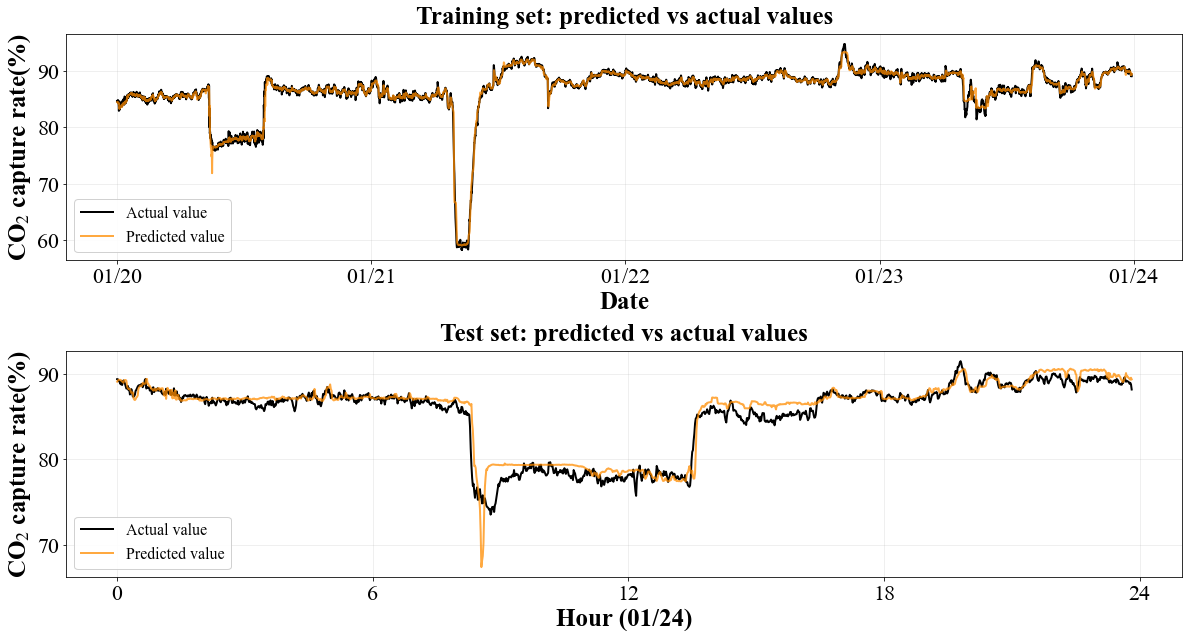

✓ Visualization saved as 'time_series_prediction_results.png'
  • Training date range: 01/20 to 01/24 (total 5750 points)
  • Test time range: 01/24 (total 23.82 hours)


In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# Ensure the 1st figure always displays inline (even if backend changed later)
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

# Close any previously-open figures (prevents showing old sensitivity-analysis plots)
plt.close('all')

# Convert capture-rate values to 0–100 scale (ticks show numbers without %)
_capture_candidates = [y_train_windows, y_train_pred, y_test_windows, y_test_pred]
_capture_max = np.nanmax([np.nanmax(np.asarray(v)) for v in _capture_candidates])
_need_times_100 = _capture_max <= 1.5

def _to_pct_values(arr):
    arr = np.asarray(arr)
    return arr * 100.0 if _need_times_100 else arr

y_train_windows_pct = _to_pct_values(y_train_windows)
y_train_pred_pct = _to_pct_values(y_train_pred)
y_test_windows_pct = _to_pct_values(y_test_windows)
y_test_pred_pct = _to_pct_values(y_test_pred)

# Use Times New Roman + 12pt for the whole figure
with plt.rc_context({'font.family': 'Times New Roman', 'font.size': 12}):
    # Keep only two plots: full training sequence + full test sequence
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 1, hspace=0.40)

    # Training set: create date sequence (01/20 to 01/24)
    train_start_date = datetime(2026, 1, 20)
    train_dates = [train_start_date + timedelta(minutes=i) for i in range(len(y_train_windows))]

    # Test set: create hour sequence (0-24h)
    test_hours = np.arange(len(y_test_windows)) / 60  # Convert to hours (1 point per minute)

    # Plot 1: training-set prediction vs actual (full sequence)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(train_dates, y_train_windows_pct, '-', label='Actual value', linewidth=2, color='black')
    ax1.plot(train_dates, y_train_pred_pct, '-', label='Predicted value', linewidth=2, alpha=0.75, color='darkorange')
    ax1.set_xlabel('Date', fontsize=25, fontweight='bold')
    ax1.set_ylabel('CO$_2$ capture rate(%)', fontsize=25, fontweight='bold')
    ax1.set_title('Training set: predicted vs actual values', fontweight='bold', fontsize=25, pad=10)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax1.xaxis.set_major_locator(mdates.DayLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0, ha='center', fontsize=12)
    ax1.tick_params(axis='both', labelsize=22)
    ax1.legend(loc='best', fontsize=16, framealpha=0.9)
    ax1.grid(True, alpha=0.25, linewidth=0.8)

    # Plot 2: test-set prediction vs actual (full sequence)
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(test_hours, y_test_windows_pct, '-', label='Actual value', linewidth=2, color='black')
    ax2.plot(test_hours, y_test_pred_pct, '-', label='Predicted value', linewidth=2, alpha=0.75, color='darkorange')
    ax2.set_xlabel('Hour (01/24)', fontsize=25, fontweight='bold')
    ax2.set_ylabel('CO$_2$ capture rate(%)', fontsize=25, fontweight='bold')
    ax2.set_title('Test set: predicted vs actual values', fontweight='bold', fontsize=25, pad=10)
    # Set x-axis ticks every 6 hours
    ax2.set_xticks(np.arange(0, max(test_hours) + 1, 6))
    ax2.tick_params(axis='both', labelsize=22)
    ax2.legend(loc='best', fontsize=16, framealpha=0.9)
    ax2.grid(True, alpha=0.25, linewidth=0.8)

    plt.savefig('time_series_prediction_results.png', dpi=300, bbox_inches='tight')
    plt.show()

print("✓ Visualization saved as 'time_series_prediction_results.png'")
print(f"  • Training date range: 01/20 to 01/24 (total {len(y_train_windows)} points)")
print(f"  • Test time range: 01/24 (total {test_hours.max():.2f} hours)")

## Step 8: Feature Importance Analysis


[Feature Importance Analysis]
       Feature  Total importance  Mean importance
         TI-34          0.760092         0.076009
         TI-28          0.177034         0.017703
         TI-19          0.023605         0.002360
         TI-12          0.012758         0.001276
         TI-33          0.011580         0.001158
         TI-22          0.005135         0.000513
          TI-4          0.003939         0.000394
Level Reboiler          0.002528         0.000253
         TI-24          0.002048         0.000205
         FI-30          0.000740         0.000074
         FI-38          0.000540         0.000054


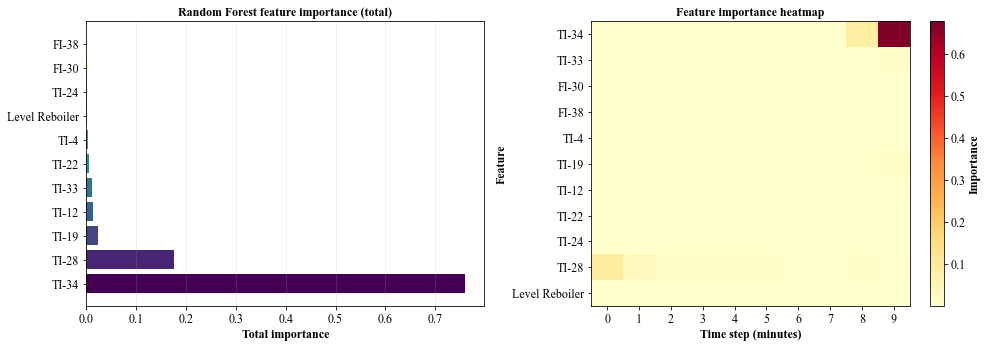


✓ Feature-importance figure saved as 'feature_importance_analysis.png'


In [9]:
# Ensure the 2nd figure always displays inline (even if backend changed later)
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

# Use Times New Roman + 12pt for the whole Figure 2
with plt.rc_context({'font.family': 'Times New Roman', 'font.size': 12}):
    # Get feature importance
    feature_importance = rf_model.feature_importances_

    # Input is flattened windowed data, so reshape is required
    # Shape: (10 minutes × 10 features) = 100 dimensions
    n_features_per_window = len(selected_features)  # 10
    window_size = 10

    # Group importance by time step and feature
    importance_matrix = feature_importance.reshape(window_size, n_features_per_window)

    # Total importance for each feature across all time steps
    feature_total_importance = importance_matrix.sum(axis=0)
    feature_importance_df = pd.DataFrame({
        'Feature': selected_features,
        'Total importance': feature_total_importance,
        'Mean importance': feature_total_importance / window_size
    }).sort_values('Total importance', ascending=False)

    print("\n[Feature Importance Analysis]")
    print(feature_importance_df.to_string(index=False))

    # Visualize feature importance
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: total feature importance bar chart
    ax1 = axes[0]
    colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance_df)))
    ax1.barh(range(len(feature_importance_df)), feature_importance_df['Total importance'], color=colors)
    ax1.set_yticks(range(len(feature_importance_df)))
    ax1.set_yticklabels(feature_importance_df['Feature'])
    ax1.set_xlabel('Total importance', fontsize=12, fontweight='bold')
    ax1.set_title('Random Forest feature importance (total)', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='both', labelsize=12)
    ax1.grid(True, alpha=0.25, linewidth=0.8, axis='x')

    # Plot 2: heatmap of feature importance over time steps
    ax2 = axes[1]
    im = ax2.imshow(importance_matrix.T, aspect='auto', cmap='YlOrRd')
    ax2.set_xlabel('Time step (minutes)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Feature', fontsize=12, fontweight='bold')
    ax2.set_xticks(range(window_size))
    ax2.set_yticks(range(len(selected_features)))
    ax2.set_yticklabels(selected_features)
    ax2.set_title('Feature importance heatmap', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='both', labelsize=12)
    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label('Importance', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()
    plt.savefig('feature_importance_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n✓ Feature-importance figure saved as 'feature_importance_analysis.png'")

In [10]:
# If later plots are not displayed, it is usually because the backend was switched to non-interactive mode (e.g., agg).
# Explicitly restore inline rendering so subsequent plt.show() outputs are visible in the notebook.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

import matplotlib.pyplot as plt
plt.ion()
print("✓ Restored plotting output (matplotlib inline)")

✓ Restored plotting output (matplotlib inline)


## Step 9: Result Summary and Export

In [11]:
# Create summary report
def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

top5_lines = []
try:
    _fcol = _pick_col(feature_importance_df, ['Feature'])
    _icol = _pick_col(feature_importance_df, ['Total importance'])
    if _fcol is not None and _icol is not None and len(feature_importance_df) > 0:
        for i in range(min(5, len(feature_importance_df))):
            feat_name = feature_importance_df.iloc[i][_fcol]
            feat_imp = float(feature_importance_df.iloc[i][_icol])
            top5_lines.append(f"  • {feat_name}: {feat_imp:.4f}")
    else:
        top5_lines.append("  • (feature importance not available)")
except Exception:
    top5_lines.append("  • (feature importance not available)")

top5_text = "\n".join(top5_lines)

summary_report = f"""
{'='*80}
Time-Series Prediction Model Performance Summary
{'='*80}

[Data Configuration]
  • Number of raw data points: {len(df)}
  • Sampling frequency: 1 point per minute
  • Time span: about {len(df)} minutes
  • Number of selected features: {len(selected_features)}

[Data Split]
  • Training set: {len(X_train_raw)} rows (first 80%)
  • Test set: {len(X_test_raw)} rows (last 20%)
  • Training windows: {len(X_train_windows)} (10 minutes per window)
  • Test windows: {len(X_test_windows)} (10 minutes per window)

[Model Configuration]
  • Model type: Random Forest Regressor
  • Number of trees: {rf_model.n_estimators}
  • Input dimension: {X_train_windows.shape[1]} (10 minutes × {len(selected_features)} features)
  • Prediction task: previous 10 minutes → next 1 minute

[Performance Metrics]

  Training set:
    • R²: {train_r2:.4f}
    • RMSE: {train_rmse:.6f}
    • MAE: {train_mae:.6f}
    • WQL: {train_wql:.6f}

  Test set:
    • R²: {test_r2:.4f}
    • RMSE: {test_rmse:.6f}
    • MAE: {test_mae:.6f}
    • WQL: {test_wql:.6f}

[Metric Notes]
  • R²: proportion of explained variance, range [0, 1], closer to 1 is better
  • RMSE: square-rooted mean squared error, more sensitive to large errors
  • MAE: mean absolute error, more robust to outliers
  • WQL: measures symmetry and balance of prediction errors
    └─ If prediction < actual (under-prediction), weight is 0.5
    └─ If prediction > actual (over-prediction), weight is 0.5
    └─ Smaller WQL means more balanced predictions with less systematic bias

[Accuracy Interpretation]
  • R² = {test_r2:.4f}: model explains {test_r2*100:.2f}% of test-set variance
  • RMSE = {test_rmse:.6f}: average prediction error on original scale
  • MAE = {test_mae:.6f}: mean absolute deviation
  • WQL = {test_wql:.6f}: prediction-balance indicator (closer to 0 is better)

[Residual Analysis]
  • Residual mean: {residuals_mean:.6f} (close to 0 indicates unbiased predictions)
  • Residual std: {residuals_std:.6f}
  • Residual range: [{residuals.min():.6f}, {residuals.max():.6f}]

[Top 5 Important Features]
{top5_text}

{'='*80}
"""

print(summary_report)

# Save report
with open('time_series_prediction_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)
print("✓ Report saved as 'time_series_prediction_report.txt'")


Time-Series Prediction Model Performance Summary

[Data Configuration]
  • Number of raw data points: 7200
  • Sampling frequency: 1 point per minute
  • Time span: about 7200 minutes
  • Number of selected features: 11

[Data Split]
  • Training set: 5760 rows (first 80%)
  • Test set: 1440 rows (last 20%)
  • Training windows: 5750 (10 minutes per window)
  • Test windows: 1430 (10 minutes per window)

[Model Configuration]
  • Model type: Random Forest Regressor
  • Number of trees: 400
  • Input dimension: 110 (10 minutes × 11 features)
  • Prediction task: previous 10 minutes → next 1 minute

[Performance Metrics]

  Training set:
    • R²: 0.9882
    • RMSE: 0.005040
    • MAE: 0.002902
    • WQL: 0.001451

  Test set:
    • R²: 0.9253
    • RMSE: 0.011367
    • MAE: 0.007446
    • WQL: 0.003723

[Metric Notes]
  • R²: proportion of explained variance, range [0, 1], closer to 1 is better
  • RMSE: square-rooted mean squared error, more sensitive to large errors
  • MAE: mean abs

In [12]:
# Save prediction results to CSV
results_df = pd.DataFrame({
    'Time step': np.arange(len(y_test_windows)),
    'Actual value': y_test_windows,
    'Predicted value': y_test_pred,
    'Residual': residuals,
    'Absolute error': np.abs(residuals),
    'Relative error (%)': np.abs(residuals) / np.abs(y_test_windows) * 100
})

results_df.to_csv('time_series_predictions.csv', index=False, encoding='utf-8-sig')
print("✓ Prediction results saved as 'time_series_predictions.csv'")

# Save test-set predictions to Excel (Time + Predicted Value only)
time_series_all = pd.to_datetime(df[time_col])
time_test = time_series_all.iloc[split_idx:].reset_index(drop=True)
window_size_for_export = len(X_test_raw) - len(y_test_windows)
test_time_aligned = time_test.iloc[
    window_size_for_export:window_size_for_export + len(y_test_pred)
].reset_index(drop=True)

test_pred_excel_df = pd.DataFrame({
    'Time': test_time_aligned,
    'Predicted Value': y_test_pred
})
test_pred_excel_df.to_excel('test_predictions.xlsx', index=False)
print("✓ Test predictions Excel saved as 'test_predictions.xlsx'")

# Save performance metric summary
metrics_summary = pd.DataFrame({
    'Metric': ['R²', 'RMSE', 'MAE', 'Residual mean', 'Residual std'],
    'Train set': [train_r2, train_rmse, train_mae, np.nan, np.nan],
    'Test set': [test_r2, test_rmse, test_mae, residuals_mean, residuals_std]
})

metrics_summary.to_csv('performance_metrics.csv', index=False, encoding='utf-8-sig')
print("✓ Performance metrics saved as 'performance_metrics.csv'")

print("\n" + "="*80)
print("✅ All files generated successfully!")
print("="*80)
print("\nGenerated files:")
print("  1. time_series_prediction_results.png - prediction visualization")
print("  2. feature_importance_analysis.png - feature importance analysis")
print("  3. time_series_prediction_report.txt - performance summary report")
print("  4. time_series_predictions.csv - detailed prediction results")
print("  5. test_predictions.xlsx - test set predicted values (Time + Predicted Value)")
print("  6. performance_metrics.csv - performance metric summary")

✓ Prediction results saved as 'time_series_predictions.csv'
✓ Test predictions Excel saved as 'test_predictions.xlsx'
✓ Performance metrics saved as 'performance_metrics.csv'

✅ All files generated successfully!

Generated files:
  1. time_series_prediction_results.png - prediction visualization
  2. feature_importance_analysis.png - feature importance analysis
  3. time_series_prediction_report.txt - performance summary report
  4. time_series_predictions.csv - detailed prediction results
  5. test_predictions.xlsx - test set predicted values (Time + Predicted Value)
  6. performance_metrics.csv - performance metric summary


## Step 10: SHAP Explainability Analysis

**SHAP (SHapley Additive exPlanations)** is an explainability method for interpreting machine-learning model predictions.

### Two key plots

1. **Summary Plot** - global view
   - Shows overall feature impact on model predictions
   - X-axis: SHAP value (feature contribution)
   - Y-axis: feature name (sorted by importance)
   - Color: feature value level (red=high, blue=low)
   - **Use case**: identify the most important features and their influence direction

2. **Waterfall Plot** - single-sample view
   - Shows how one prediction is composed
   - Starts from a base value and accumulates feature contributions
   - Red: positive contribution (pushes prediction up)
   - Blue: negative contribution (pulls prediction down)
   - **Use case**: explain predictions at specific time points and diagnose anomalies

In [13]:
# Step 1: Create meaningful feature names
print("="*80)
print("Start SHAP explainability analysis")
print("="*80)

# Build feature names: each raw feature across 10 time steps
feature_names = []
for t in range(10, 0, -1):  # from t-10 to t-1
    for feat in selected_features:
        feature_names.append(f'{feat}_t-{t}')

print(f"\n✓ Generated {len(feature_names)} feature names")
print(f"  Example: {feature_names[:5]}")
print(f"           {feature_names[-5:]}")

# Create DataFrames with feature names (for SHAP analysis)
X_train_df = pd.DataFrame(X_train_windows, columns=feature_names)
X_test_df = pd.DataFrame(X_test_windows, columns=feature_names)

print(f"\nTrain shape: {X_train_df.shape}")
print(f"Test shape: {X_test_df.shape}")

Start SHAP explainability analysis

✓ Generated 110 feature names
  Example: ['TI-34_t-10', 'TI-33_t-10', 'FI-30_t-10', 'FI-38_t-10', 'TI-4_t-10']
           ['TI-12_t-1', 'TI-22_t-1', 'TI-24_t-1', 'TI-28_t-1', 'Level Reboiler_t-1']

Train shape: (5750, 110)
Test shape: (1430, 110)


In [14]:
# Step 2: Create SHAP TreeExplainer (optimized for tree models)
print("\n" + "="*80)
print("Create SHAP TreeExplainer")
print("="*80)

# Compatibility patch: np.int removed in NumPy 1.20+
import numpy as np
if not hasattr(np, 'int'):
    np.int = int
    np.float = float
    np.complex = complex
    np.object = object
    np.bool = bool

# Use background dataset (sample 500 points for speed)
background_data = shap.sample(X_train_df, 500, random_state=42)
print(f"✓ Background dataset: {background_data.shape[0]} samples")

# Create TreeExplainer
explainer = shap.TreeExplainer(rf_model, background_data)
print(f"✓ TreeExplainer created")
print(f"  • Model type: {type(rf_model).__name__}")
print(f"  • Number of features: {len(feature_names)}")


Create SHAP TreeExplainer
✓ Background dataset: 500 samples
✓ TreeExplainer created
  • Model type: RandomForestRegressor
  • Number of features: 110


In [15]:
print("\n" + "="*80)
print("Plot SHAP summary chart (aggregated by raw features)")
print("="*80)

# Compute SHAP values on test samples for summary chart
print(f"\nCompute SHAP values on test set, total samples: {len(X_test_df)}")
shap_values_test = explainer.shap_values(X_test_df)


Plot SHAP summary chart (aggregated by raw features)

Compute SHAP values on test set, total samples: 1430


 98%|===================| 1407/1430 [00:51<00:00]        


Plot SHAP summary chart (aggregated by raw features)
✓ SHAP values aggregated into 11 raw features
  • Aggregated shape: (1430, 11)


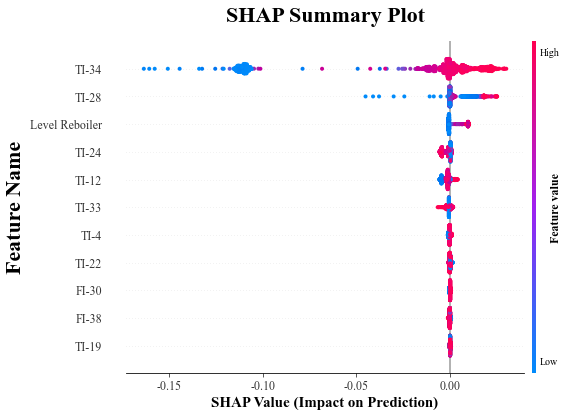

✓ SHAP summary chart saved: shap_summary_plot_combined.png

[Chart Notes]
  • Sample source: test-set samples
  • X-axis: SHAP value (positive pushes prediction up, negative pushes down)
  • Y-axis: 11 raw feature names (sorted by importance)
  • Color: feature magnitude (red=high, blue=low)
  • Note: each feature's SHAP value is summed across 10 time steps
  • Use case: identify key features and understand their impact on CO2-capacity prediction


In [16]:
# Step 4: Plot SHAP summary plot (aggregated by 11 raw features)
print("\n" + "="*80)
print("Plot SHAP summary chart (aggregated by raw features)")
print("="*80)

import matplotlib.ticker as mticker

# Aggregate 110-dim SHAP values into 11 raw features
shap_values_aggregated = np.zeros((shap_values_test.shape[0], len(selected_features)))
X_test_aggregated = np.zeros((X_test_df.shape[0], len(selected_features)))

for i, feat in enumerate(selected_features):
    # Indices for this feature across all time steps
    feat_indices = [idx for idx, name in enumerate(feature_names) if name.startswith(feat + '_')]
    # Aggregate SHAP values (sum)
    shap_values_aggregated[:, i] = shap_values_test[:, feat_indices].sum(axis=1)
    # Aggregate feature values (mean)
    X_test_aggregated[:, i] = X_test_df.iloc[:, feat_indices].mean(axis=1)

# Keep 4 decimal places for display
shap_values_aggregated = np.round(shap_values_aggregated, 4)
X_test_aggregated = np.round(X_test_aggregated, 4)

print(f"✓ SHAP values aggregated into 11 raw features")
print(f"  • Aggregated shape: {shap_values_aggregated.shape}")

# Create figure and main axis
fig, ax = plt.subplots(figsize=(12, 8))

# Plot SHAP summary (disable auto color bar explicitly)
shap.summary_plot(
    shap_values_aggregated,
    pd.DataFrame(X_test_aggregated, columns=selected_features),
    show=False,
    plot_type='dot',  # Explicitly use dot plot
    color_bar=False   # Disable auto color bar
)

# Get current axis
ax = plt.gca()

# Axis format
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Manually create color bar
scatter_collections = [c for c in ax.collections if hasattr(c, 'get_array')]
if scatter_collections:
    scatter = scatter_collections[0]

    # SHAP-like color map: blue -> red
    from matplotlib.colors import LinearSegmentedColormap
    colors_list = ['#008bfb', '#a020f0', '#ff0051']
    n_bins = 256
    cmap = LinearSegmentedColormap.from_list('shap', colors_list, N=n_bins)
    scatter.set_cmap(cmap)

    # Add color-bar axis
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="1%", pad=0.1)

    # Draw color bar
    cbar = plt.colorbar(scatter, cax=cax)
    cbar.set_label('Feature value', fontsize=12, fontweight='bold', labelpad=15)
    cbar.ax.tick_params(labelsize=11)
    cbar.set_ticks([])
    cbar.outline.set_visible(False)

    # Add Low/High labels
    cbar.ax.text(2, 0.02, 'Low', fontsize=10, va='bottom', ha='left', transform=cbar.ax.transAxes)
    cbar.ax.text(2, 0.98, 'High', fontsize=10, va='top', ha='left', transform=cbar.ax.transAxes)
else:
    ax.text(1.02, 0.5, 'Feature value\nLow ← → High',
            transform=ax.transAxes,
            fontsize=11, va='center', ha='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# Title and labels
ax.set_title('SHAP Summary Plot', fontsize=22, fontweight='bold', pad=20)
ax.set_xlabel('SHAP Value (Impact on Prediction)', fontsize=15, fontweight='bold')
ax.set_ylabel('Feature Name', fontsize=22, fontweight='bold')

plt.tight_layout()
plt.savefig('shap_summary_plot_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ SHAP summary chart saved: shap_summary_plot_combined.png")
print(f"\n[Chart Notes]")
print(f"  • Sample source: test-set samples")
print(f"  • X-axis: SHAP value (positive pushes prediction up, negative pushes down)")
print(f"  • Y-axis: 11 raw feature names (sorted by importance)")
print(f"  • Color: feature magnitude (red=high, blue=low)")
print(f"  • Note: each feature's SHAP value is summed across 10 time steps")
print(f"  • Use case: identify key features and understand their impact on CO2-capacity prediction")

In [17]:
# Step 5: Select representative samples for waterfall plots
print("\n" + "="*80)
print("Select representative samples for SHAP waterfall plots")
print("="*80)

# Select representative samples from test set
errors = y_test_windows - y_test_pred
abs_errors = np.abs(errors)

# Select 3 representative samples
max_actual_idx = np.argmax(y_test_windows)
min_actual_idx = np.argmin(y_test_windows)
min_error_idx = np.argmin(abs_errors)

typical_samples = [
    ('Max actual value sample', max_actual_idx, 'blue'),
    ('Min actual value sample', min_actual_idx, 'purple'),
    ('Most accurate prediction sample', min_error_idx, 'green')
]

print(f"\nSelected 3 representative samples:")
for name, idx, color in typical_samples:
    print(f"  • {name}: sample index={idx}, actual={y_test_windows[idx]:.6f}, "
          f"predicted={y_test_pred[idx]:.6f}, error={errors[idx]:.6f}")


Select representative samples for SHAP waterfall plots

Selected 3 representative samples:
  • Max actual value sample: sample index=1188, actual=0.914714, predicted=0.902620, error=0.012094
  • Min actual value sample: sample index=526, actual=0.735384, predicted=0.792856, error=-0.057472
  • Most accurate prediction sample: sample index=799, actual=0.775935, predicted=0.775934, error=0.000002



Plot SHAP waterfall charts (3 representative samples, aggregated by 11 raw features)

[SHAP Statistics]
  • Base value (Expected value): 0.8792 (87.92%)
  • Test prediction range: [0.6740, 0.9059]
  • Test actual range: [0.7354, 0.9147]

[SHAP Verification (Sample 1)]
  • Base value: 0.8792
  • Sum of SHAP values: 0.0116
  • Base + SHAP sum: 0.8907
  • Predicted value: 0.8907
  • Absolute gap: 0.0000

Drawing chart 1: Max actual value sample...

[Aggregated SHAP Values (Sample 1: Max actual value sample)]
  • Range: [-0.0011, 0.0256]
  • Sum: 0.0235
  • Per-feature SHAP values (percentage format):
      TI-34          : +      2.56%
      TI-33          :      -0.06%
      FI-30          : +      0.02%
      FI-38          :      -0.11%
      TI-4           : +     -0.00%
      TI-19          : +      0.02%
      TI-12          :      -0.10%
      TI-22          :      -0.02%
      TI-24          :      -0.02%
      TI-28          : +      0.11%
      Level Reboiler :      -0.05%

[Ma

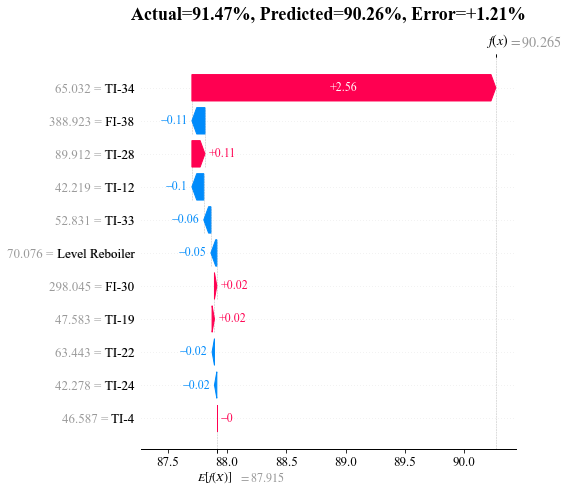

  ✓ Saved: shap_waterfall_1_Max_actual_value_sample.png

Drawing chart 2: Min actual value sample...

[Min actual value sample - SHAP Details (Percentage)]
  TI-34          : -11.11%
  TI-33          : -0.05%
  FI-30          : -0.05%
  FI-38          : -0.01%
  TI-4           : +-0.00%
  TI-19          : +-0.00%
  TI-12          : -0.53%
  TI-22          : +0.00%
  TI-24          : -0.04%
  TI-28          : +2.23%
  Level Reboiler : +0.94%


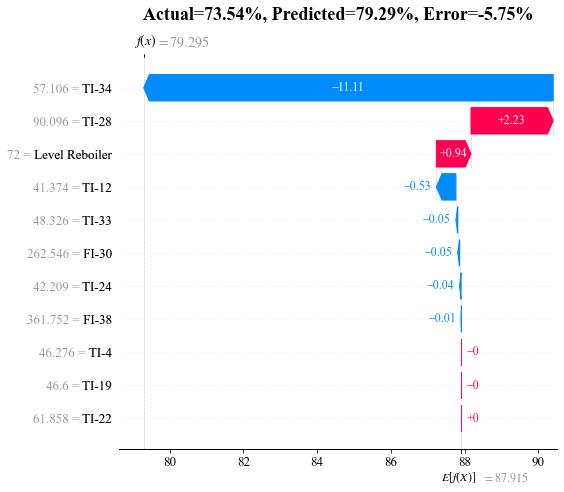

  ✓ Saved: shap_waterfall_2_Min_actual_value_sample.png

Drawing chart 3: Most accurate prediction sample...

[Most accurate prediction sample - SHAP Details (Percentage)]
  TI-34          : -11.37%
  TI-33          : -0.06%
  FI-30          : -0.04%
  FI-38          : +0.02%
  TI-4           : -0.07%
  TI-19          : -0.01%
  TI-12          : -0.44%
  TI-22          : +0.00%
  TI-24          : +0.02%
  TI-28          : +0.74%
  Level Reboiler : +0.90%


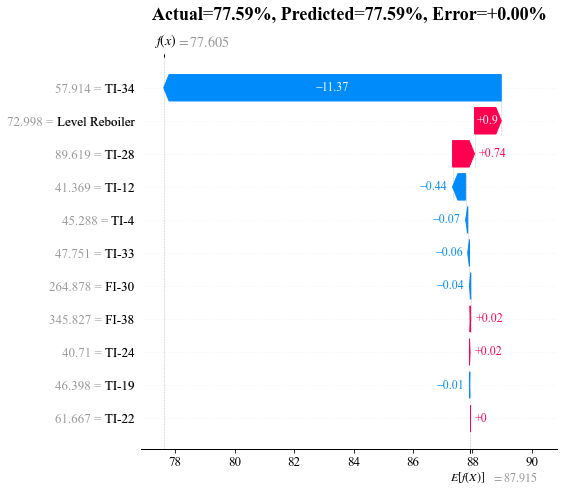

  ✓ Saved: shap_waterfall_3_Most_accurate_prediction_sample.png

✓ All SHAP waterfall charts saved:
    - shap_waterfall_1_Max_actual_value_sample.png
    - shap_waterfall_2_Min_actual_value_sample.png
    - shap_waterfall_3_Most_accurate_prediction_sample.png

[Chart Notes]
  • E[f(x)]: base value (mean prediction over all samples, percentage format)
  • f(x): predicted value for current sample (percentage format)
  • Red/pink: positive contribution (pushes prediction up)
  • Blue: negative contribution (pushes prediction down)
  • SHAP values are shown in percentage format (scaled by 100 and suffixed with %)
  • Arrows show accumulation from base value to final prediction
  • Error: positive=overestimation, negative=underestimation

[Sample Types]
  • Max actual value sample: highest CO2-capacity sample
  • Min actual value sample: lowest CO2-capacity sample
  • Most accurate prediction sample: sample with minimum error
[-1.137e+01 -6.000e-02 -4.000e-02  2.000e-02 -7.000e-02 -1.000e-

In [49]:
# Step 6: Plot waterfall charts (3 representative samples)
print("\n" + "="*80)
print("Plot SHAP waterfall charts (3 representative samples, aggregated by 11 raw features)")
print("="*80)

# Use a publication-style font and slightly larger text for SCI figures
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 12,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Print SHAP statistics first
print(f"\n[SHAP Statistics]")
print(f"  • Base value (Expected value): {explainer.expected_value:.4f} ({explainer.expected_value*100:.2f}%)")
print(f"  • Test prediction range: [{y_test_pred.min():.4f}, {y_test_pred.max():.4f}]")
print(f"  • Test actual range: [{y_test_windows.min():.4f}, {y_test_windows.max():.4f}]")

# Verify SHAP sum on first sample
idx_check = 0
shap_sum_check = shap_values_test[idx_check].sum()
pred_check = y_test_pred[idx_check]
print(f"\n[SHAP Verification (Sample 1)]")
print(f"  • Base value: {explainer.expected_value:.4f}")
print(f"  • Sum of SHAP values: {shap_sum_check:.4f}")
print(f"  • Base + SHAP sum: {explainer.expected_value + shap_sum_check:.4f}")
print(f"  • Predicted value: {pred_check:.4f}")
print(f"  • Absolute gap: {abs((explainer.expected_value + shap_sum_check) - pred_check):.4f}")

# Draw one waterfall per representative sample
saved_files = []
for i, (name, idx, color) in enumerate(typical_samples, 1):
    print(f"\nDrawing chart {i}: {name}...")

    # Aggregate SHAP values to 11 raw features for this sample
    shap_values_aggregated_sample = np.zeros(len(selected_features))
    X_aggregated_sample = np.zeros(len(selected_features))

    for j, feat in enumerate(selected_features):
        feat_indices = [k for k, name_k in enumerate(feature_names) if name_k.startswith(feat + '_')]
        shap_values_aggregated_sample[j] = shap_values_test[idx, feat_indices].sum()
        X_aggregated_sample[j] = X_test_df.iloc[idx, feat_indices].mean()

    # Keep 4 decimals for display
    shap_values_aggregated_sample = np.round(shap_values_aggregated_sample, 4)
    X_aggregated_sample = np.round(X_aggregated_sample, 4)

    # Print details for first sample only
    if i == 1:
        print(f"\n[Aggregated SHAP Values (Sample 1: {name})]")
        print(f"  • Range: [{shap_values_aggregated_sample.min():.4f}, {shap_values_aggregated_sample.max():.4f}]")
        print(f"  • Sum: {shap_values_aggregated_sample.sum():.4f}")
        print(f"  • Per-feature SHAP values (percentage format):")
        for feat_name, shap_val in zip(selected_features, shap_values_aggregated_sample):
            shap_pct = shap_val * 100
            sign = "+" if shap_pct >= 0 else ""
            print(f"      {feat_name:<15}: {sign}{shap_pct:>10.2f}%")

    # Actual / predicted / error for this sample
    actual = y_test_windows[idx]
    pred = y_test_pred[idx]
    error = errors[idx]

    # Scale all values by 100 (percentage view)
    shap_values_percentage = shap_values_aggregated_sample * 100
    base_value_percentage = explainer.expected_value * 100
    actual_percentage = actual * 100
    pred_percentage = pred * 100
    error_percentage = error * 100

    # Build SHAP Explanation object
    shap_exp = shap.Explanation(
        values=shap_values_percentage,
        base_values=base_value_percentage,
        data=X_aggregated_sample,
        feature_names=selected_features
    )

    # Plot waterfall (default SHAP style)
    shap.waterfall_plot(shap_exp, max_display=11, show=False)

    # Get current figure/axis
    fig = plt.gcf()
    ax = plt.gca()
    ax.tick_params(axis='both', labelsize=14)

    # Add % sign to numeric text labels if missing
    for text in ax.texts:
        current_text = text.get_text()
        if current_text:
            try:
                cleaned_text = current_text.replace('+', '').replace('−', '-').replace('−', '-')
                _ = float(cleaned_text)
                if '%' not in current_text:
                    text.set_text(current_text + '%')
            except ValueError:
                pass

    # Title in percentage format
    ax.set_title(f'Actual={actual_percentage:.2f}%, Predicted={pred_percentage:.2f}%, Error={error_percentage:+.2f}%',
                 fontsize=18, fontweight='bold', color='black', pad=12)

    # Print SHAP values to console (percentage format)
    print(f"\n[{name} - SHAP Details (Percentage)]")
    for feat_name, shap_val in zip(selected_features, shap_values_aggregated_sample):
        shap_pct = shap_val * 100
        sign = "+" if shap_pct >= 0 else ""
        print(f"  {feat_name:15s}: {sign}{shap_pct:.2f}%")

    plt.tight_layout()

    # Save single chart
    filename = f'shap_waterfall_{i}_{name.replace(" ", "_")}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0.3)
    plt.show()
    saved_files.append(filename)
    print(f"  ✓ Saved: {filename}")

    # Close figure and free memory
    plt.close(fig)

print(f"\n✓ All SHAP waterfall charts saved:")
for filename in saved_files:
    print(f"    - {filename}")
print(f"\n[Chart Notes]")
print(f"  • E[f(x)]: base value (mean prediction over all samples, percentage format)")
print(f"  • f(x): predicted value for current sample (percentage format)")
print(f"  • Red/pink: positive contribution (pushes prediction up)")
print(f"  • Blue: negative contribution (pushes prediction down)")
print(f"  • SHAP values are shown in percentage format (scaled by 100 and suffixed with %)")
print(f"  • Arrows show accumulation from base value to final prediction")
print(f"  • Error: positive=overestimation, negative=underestimation")
print(f"\n[Sample Types]")
print(f"  • Max actual value sample: highest CO2-capacity sample")
print(f"  • Min actual value sample: lowest CO2-capacity sample")
print(f"  • Most accurate prediction sample: sample with minimum error")
print(shap_values_percentage)

In [50]:
# Step 7: SHAP analysis summary report
print("\n" + "="*80)
print("SHAP analysis summary report")
print("="*80)

# Compute mean absolute SHAP values and identify most important features
mean_abs_shap = np.abs(shap_values_test).mean(axis=0)

# Sort by importance
top_n = 10
top_indices = np.argsort(mean_abs_shap)[::-1][:top_n]

print(f"\n[Test Set] Top {top_n} most important features (sorted by mean |SHAP|):")
for rank, idx in enumerate(top_indices, 1):
    print(f"  {rank}. {feature_names[idx]:<20} | mean|SHAP|={mean_abs_shap[idx]:.4f}")

# Save SHAP importance to CSV
shap_importance_df = pd.DataFrame({
    'Feature Name': feature_names,
    'Mean Absolute SHAP': np.round(mean_abs_shap, 4)
})
shap_importance_df = shap_importance_df.sort_values('Mean Absolute SHAP', ascending=False)
shap_importance_df.to_csv('shap_feature_importance.csv', index=False, encoding='utf-8-sig')

print(f"\n✓ SHAP feature importance saved: shap_feature_importance.csv")

print("\n" + "="*80)
print("✅ SHAP analysis completed!")
print("="*80)
print("\nGenerated files:")
print("  1. shap_summary_plot_combined.png - SHAP summary plot")
print("  2. shap_waterfall_1_max_actual_value_sample.png - Waterfall plot 1")
print("  3. shap_waterfall_2_min_actual_value_sample.png - Waterfall plot 2")
print("  4. shap_waterfall_3_most_accurate_prediction_sample.png - Waterfall plot 3")
print("  5. shap_feature_importance.csv - SHAP feature-importance ranking")

print("\n[SHAP Analysis Summary]")
print(f"  • Model type: {type(rf_model).__name__}")
print(f"  • Data source: test-set samples (total {len(X_test_df)} samples)")
print(f"  • Number analyzed: {len(X_test_df)} samples (test set)")
print(f"  • Feature dimension: {len(selected_features)} raw features × 10 time steps = {len(feature_names)} dimensions")
print(f"  • SHAP aggregation: sum by {len(selected_features)} raw features while preserving temporal info")
print(f"  • Explainability tools: summary plot (global) + waterfall plot (single sample)")


SHAP analysis summary report

[Test Set] Top 10 most important features (sorted by mean |SHAP|):
  1. TI-34_t-1            | mean|SHAP|=0.0276
  2. TI-34_t-2            | mean|SHAP|=0.0026
  3. TI-28_t-10           | mean|SHAP|=0.0010
  4. TI-12_t-2            | mean|SHAP|=0.0005
  5. TI-33_t-1            | mean|SHAP|=0.0005
  6. TI-28_t-9            | mean|SHAP|=0.0004
  7. Level Reboiler_t-5   | mean|SHAP|=0.0004
  8. TI-24_t-5            | mean|SHAP|=0.0004
  9. Level Reboiler_t-7   | mean|SHAP|=0.0004
  10. Level Reboiler_t-3   | mean|SHAP|=0.0004

✓ SHAP feature importance saved: shap_feature_importance.csv

✅ SHAP analysis completed!

Generated files:
  1. shap_summary_plot_combined.png - SHAP summary plot
  2. shap_waterfall_1_max_actual_value_sample.png - Waterfall plot 1
  3. shap_waterfall_2_min_actual_value_sample.png - Waterfall plot 2
  4. shap_waterfall_3_most_accurate_prediction_sample.png - Waterfall plot 3
  5. shap_feature_importance.csv - SHAP feature-importance ran


Plot SHAP dependence plots for key variables

[Dependence Plot] TI-34


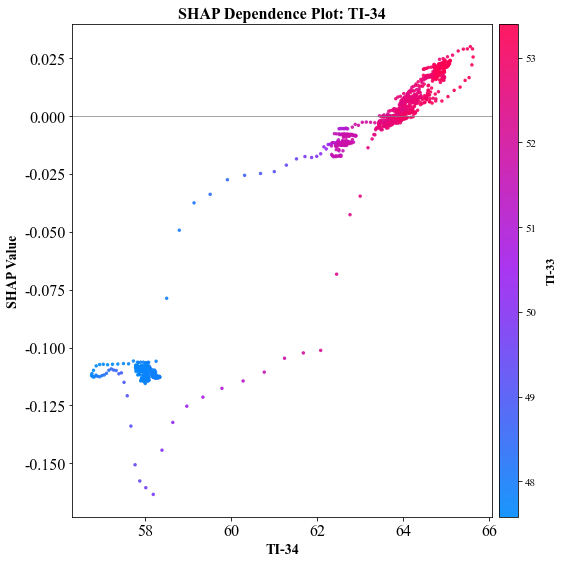

✓ Saved: shap_dependence_TI34.png  | Interaction color: TI-33

[Dependence Plot] TI-28


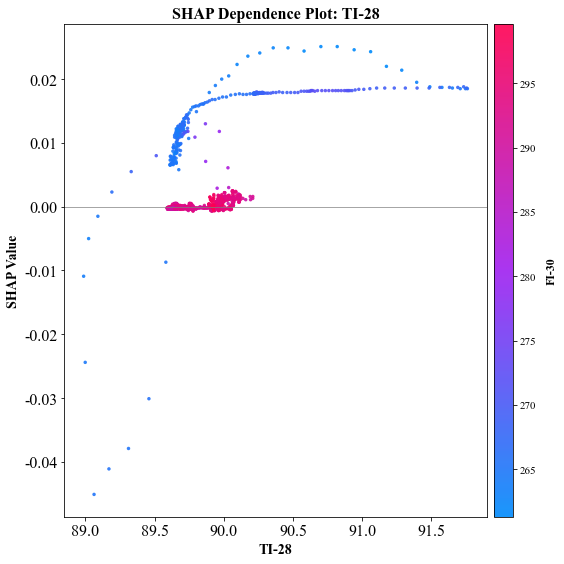

✓ Saved: shap_dependence_TI28.png  | Interaction color: FI-30

[Dependence Plot] Level Reboiler


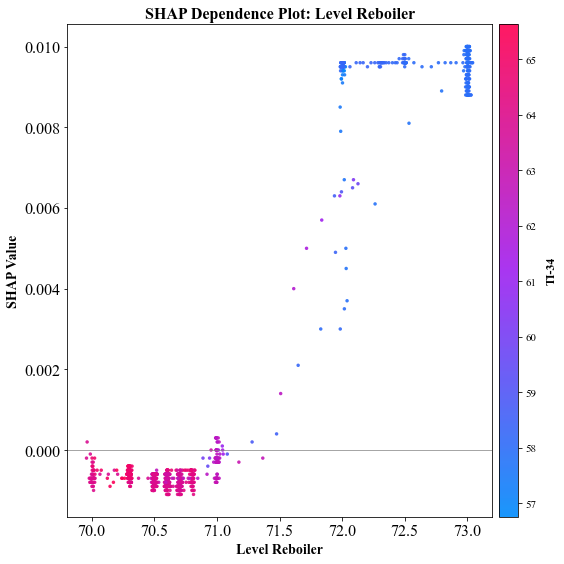

✓ Saved: shap_dependence_Level_Reboiler.png  | Interaction color: TI-34

[Dependence Plot] TI-24


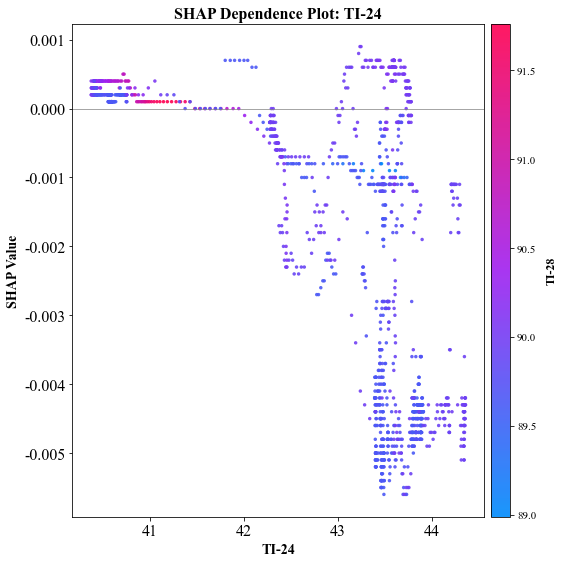

✓ Saved: shap_dependence_TI24.png  | Interaction color: TI-28

✓ Completed SHAP dependence plots for TI-34, TI-28, Level Reboiler, and TI-24


In [51]:
# Step 8: SHAP dependence plots for key variables
print("\n" + "="*80)
print("Plot SHAP dependence plots for key variables")
print("="*80)

# Rebuild the aggregated feature table used by the SHAP summary plot
shap_feature_df = pd.DataFrame(X_test_aggregated, columns=selected_features)

# Four variables requested for SHAP dependence analysis
dependence_features = ['TI-34', 'TI-28', 'Level Reboiler', 'TI-24']

# Match the notebook's reporting style and keep exported figures crisp
plt.rcParams.update({'font.family': 'Times New Roman'})

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap

# SHAP-like blue->purple->red palette
shap_cmap = LinearSegmentedColormap.from_list('shap_like', ['#008bfb', '#a020f0', '#ff0051'], N=256)

def _plot_dependence_with_fixed_colorbar(feature_name, shap_values_matrix, feature_df, feature_list, width='4.5%', pad=0.10):
    feat_idx = feature_list.index(feature_name)
    x_values = feature_df.iloc[:, feat_idx].to_numpy()
    y_values = shap_values_matrix[:, feat_idx]

    # Keep the same interaction-selection idea as SHAP auto mode
    interaction_candidates = shap.utils.approximate_interactions(feat_idx, shap_values_matrix, feature_df)
    interaction_idx = next((idx for idx in interaction_candidates if idx != feat_idx), feat_idx)
    color_values = feature_df.iloc[:, interaction_idx].to_numpy()
    interaction_name = feature_list[interaction_idx]

    fig, ax = plt.subplots(figsize=(8, 8))
    scatter = ax.scatter(
        x_values,
        y_values,
        c=color_values,
        cmap=shap_cmap,
        s=12,
        alpha=0.90,
        edgecolors='none'
    )

    ax.axhline(0, color='gray', linewidth=1.0, alpha=0.7)
    ax.set_title(f'SHAP Dependence Plot: {feature_name}', fontsize=16, fontweight='bold')
    ax.set_xlabel(feature_name, fontsize=14, fontweight='bold')
    ax.set_ylabel('SHAP Value', fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=16)

    # Stable, fixed-width colorbar for all four plots
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size=width, pad=pad)
    cbar = plt.colorbar(scatter, cax=cax)
    cbar.set_label(interaction_name, fontsize=12, fontweight='bold', labelpad=10)
    cbar.ax.tick_params(axis='y', labelsize=11)

    plt.tight_layout()
    filename = f"shap_dependence_{feature_name.replace(' ', '_').replace('-', '')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {filename}  | Interaction color: {interaction_name}")

for feat in dependence_features:
    if feat not in shap_feature_df.columns:
        print(f"Skipping {feat}: not found in SHAP feature matrix")
        continue

    print(f"\n[Dependence Plot] {feat}")
    _plot_dependence_with_fixed_colorbar(
        feat,
        shap_values_aggregated,
        shap_feature_df,
        selected_features,
        width='4.5%',
        pad=0.10
    )

print("\n✓ Completed SHAP dependence plots for TI-34, TI-28, Level Reboiler, and TI-24")

## Sensitivity Analysis: Impact of TI-34 on the Test Set

**Objective:**
- Analyze the impact of feature TI-34 on model predictions
- Time range: 6:00 to 12:00 in the test set (6 hours = 360 minutes)
- Method: replace TI-34 with its 6:00-8:00 mean value and observe prediction changes

**Steps:**
1. Extract test-set data from 6:00 to 12:00
2. Plot TI-34 original-value time series
3. Compute TI-34 statistics (mean, std, etc.)
4. Compute TI-34 mean from 6:00-8:00 and replace all TI-34 values
5. Rebuild sliding windows and predict
6. Compare original predictions vs sensitivity-test predictions

In [52]:
# Step 1: Extract test-set data from 6:00 to 12:00
print("="*80)
print("Sensitivity analysis: impact of TI-34 on prediction")
print("="*80)

# Test-set time range setup
# The test set starts from split_idx in the raw dataset
# One data point per minute, 6:00 = 360 min, 12:00 = 720 min
start_hour = 6
end_hour = 12
start_min = start_hour * 60  # 360 minutes
end_min = end_hour * 60      # 720 minutes

print(f"\n[Time Range]")
print(f"  • Analysis window: {start_hour}:00 - {end_hour}:00")
print(f"  • Corresponding index: minute {start_min} to {end_min}")

# Extract 6:00-12:00 data from raw test data
# Note: sliding windows reduce 10 samples, so extract from X_test_raw
X_test_6_12_raw = X_test_raw.iloc[start_min:end_min].copy()
y_test_6_12_raw = y_test_raw.iloc[start_min:end_min].copy()

print(f"\n[Data Extraction]")
print(f"  • Original test-set size: {len(X_test_raw)} rows")
print(f"  • 6:00-12:00 subset size: {len(X_test_6_12_raw)} rows")
print(f"  • TI-34 index in selected features: {selected_features.index('TI-34')}")

# Extract TI-34 values
ti34_values = X_test_6_12_raw['TI-34'].values
ti34_mean = ti34_values.mean()
ti34_std = ti34_values.std()
# Use mean value from 6:00-8:00 as fixed value for sensitivity analysis
ti34_values_6_8 = X_test_raw.iloc[6*60:8*60]['TI-34'].values
ti34_fixed_value = ti34_values_6_8.mean()

print(f"\n[TI-34 Statistics (6:00-12:00)]")
print(f"  • Sample count: {len(ti34_values)}")
print(f"  • Mean: {ti34_mean:.6f}")
print(f"  • Fixed value for sensitivity test (mean from 6:00-8:00): {ti34_fixed_value:.6f}")
print(f"  • Std: {ti34_std:.6f}")
print(f"  • Max: {ti34_values.max():.6f}")
print(f"  • Min: {ti34_values.min():.6f}")

Sensitivity analysis: impact of TI-34 on prediction

[Time Range]
  • Analysis window: 6:00 - 12:00
  • Corresponding index: minute 360 to 720

[Data Extraction]
  • Original test-set size: 1440 rows
  • 6:00-12:00 subset size: 360 rows
  • TI-34 index in selected features: 0

[TI-34 Statistics (6:00-12:00)]
  • Sample count: 360
  • Mean: 60.384742
  • Fixed value for sensitivity test (mean from 6:00-8:00): 63.861152
  • Std: 2.889625
  • Max: 64.136719
  • Min: 56.710361



Plot TI-34 original values (6:00-12:00)


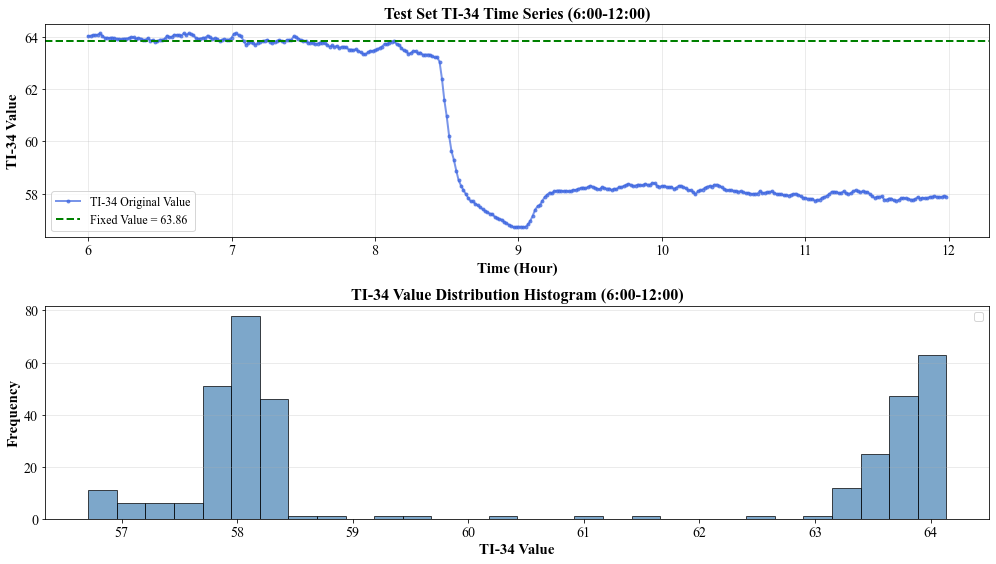

✓ TI-34 original-value chart saved: sensitivity_TI34_original_values.png


In [53]:
# Step 2: Plot TI-34 original-value time series
print("\n" + "="*80)
print("Plot TI-34 original values (6:00-12:00)")
print("="*80)

# Create time axis (minutes)
time_minutes = np.arange(len(ti34_values))
time_hours = time_minutes / 60 + start_hour  # Convert to hours, starting at 6:00

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: TI-34 time series
ax1 = axes[0]
ax1.plot(time_hours, ti34_values, 'o-', linewidth=2, markersize=3, alpha=0.7, color='royalblue', label='TI-34 Original Value')
ax1.axhline(ti34_fixed_value, color='green', linestyle='--', linewidth=2, label=f'Fixed Value = {ti34_fixed_value:.2f}')
ax1.set_xlabel('Time (Hour)', fontsize=15, fontweight='bold')
ax1.set_ylabel('TI-34 Value', fontsize=15, fontweight='bold')
ax1.set_title('Test Set TI-34 Time Series (6:00-12:00)', fontsize=16, fontweight='bold')
ax1.set_xticks(range(start_hour, end_hour + 1))
ax1.tick_params(axis='both', labelsize=14)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: TI-34 histogram
ax2 = axes[1]
ax2.hist(ti34_values, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('TI-34 Value', fontsize=15, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=15, fontweight='bold')
ax2.set_title('TI-34 Value Distribution Histogram (6:00-12:00)', fontsize=16, fontweight='bold')
ax2.tick_params(axis='both', labelsize=14)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sensitivity_TI34_original_values.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ TI-34 original-value chart saved: sensitivity_TI34_original_values.png")

In [54]:
# Step 3: Build sensitivity-test dataset (replace TI-34 with fixed value)
print("\n" + "="*80)
print("Build sensitivity-test dataset")
print("="*80)

# Copy original data
X_test_6_12_sensitivity = X_test_6_12_raw.copy()

# Replace TI-34 column with fixed value
X_test_6_12_sensitivity['TI-34'] = ti34_fixed_value

print(f"\n[Data Replacement]")
print(f"  • Original TI-34 range: [{ti34_values.min():.6f}, {ti34_values.max():.6f}]")
print(f"  • Replaced TI-34 value: {ti34_fixed_value:.6f} (constant)")
print(f"  • Other features: unchanged")

# Verify replacement
print(f"\n[Replacement Check]")
print(f"  • TI-34 unique count (original): {X_test_6_12_raw['TI-34'].nunique()}")
print(f"  • TI-34 unique count (replaced): {X_test_6_12_sensitivity['TI-34'].nunique()}")
print(f"  • Replaced TI-34 values: {X_test_6_12_sensitivity['TI-34'].unique()}")

# Build sliding windows (original data)
X_test_6_12_windows, y_test_6_12_windows = create_sliding_windows(
    X_test_6_12_raw, y_test_6_12_raw, window_size=10
)

# Build sliding windows (sensitivity-test data)
X_test_6_12_sensitivity_windows, y_test_6_12_sensitivity_windows = create_sliding_windows(
    X_test_6_12_sensitivity, y_test_6_12_raw, window_size=10
)

print(f"\n[Sliding-Window Data]")
print(f"  • Original window count: {len(X_test_6_12_windows)}")
print(f"  • Sensitivity-test window count: {len(X_test_6_12_sensitivity_windows)}")
print(f"  • Window feature dimension: {X_test_6_12_windows.shape[1]} (10 time steps × {len(selected_features)} features)")


Build sensitivity-test dataset

[Data Replacement]
  • Original TI-34 range: [56.710361, 64.136719]
  • Replaced TI-34 value: 63.861152 (constant)
  • Other features: unchanged

[Replacement Check]
  • TI-34 unique count (original): 342
  • TI-34 unique count (replaced): 1
  • Replaced TI-34 values: [63.86115189]

[Sliding-Window Data]
  • Original window count: 350
  • Sensitivity-test window count: 350
  • Window feature dimension: 110 (10 time steps × 11 features)


In [55]:
# Step 4: Model prediction comparison
print("\n" + "="*80)
print("Model prediction comparison")
print("="*80)

# Original-data prediction
y_pred_original = rf_model.predict(X_test_6_12_windows)

# Sensitivity-test prediction (TI-34 replaced by fixed value)
y_pred_sensitivity = rf_model.predict(X_test_6_12_sensitivity_windows)

# Prediction difference
pred_diff = y_pred_sensitivity - y_pred_original
abs_pred_diff = np.abs(pred_diff)

print(f"\n[Prediction Comparison]")
print(f"  • Number of samples: {len(y_pred_original)}")
print(f"\nOriginal prediction:")
print(f"  • Mean: {y_pred_original.mean():.6f}")
print(f"  • Std: {y_pred_original.std():.6f}")
print(f"  • Range: [{y_pred_original.min():.6f}, {y_pred_original.max():.6f}]")

print(f"\nSensitivity-test prediction (TI-34={ti34_fixed_value:.1f}):")
print(f"  • Mean: {y_pred_sensitivity.mean():.6f}")
print(f"  • Std: {y_pred_sensitivity.std():.6f}")
print(f"  • Range: [{y_pred_sensitivity.min():.6f}, {y_pred_sensitivity.max():.6f}]")

print(f"\nPrediction difference (sensitivity - original):")
print(f"  • Mean difference: {pred_diff.mean():.6f}")
print(f"  • Mean absolute difference: {abs_pred_diff.mean():.6f}")
print(f"  • Difference std: {pred_diff.std():.6f}")
print(f"  • Maximum positive difference: {pred_diff.max():.6f}")
print(f"  • Maximum negative difference: {pred_diff.min():.6f}")

# Relative impact (%)
relative_impact = (abs_pred_diff.mean() / y_pred_original.mean()) * 100
print(f"\n[TI-34 Sensitivity Indicator]")
print(f"  • Relative impact: {relative_impact:.2f}%")
print(f"  • Interpretation: fixing TI-34 at {ti34_fixed_value:.1f} changes prediction by {relative_impact:.2f}% on average")


Model prediction comparison

[Prediction Comparison]
  • Number of samples: 350

Original prediction:
  • Mean: 0.821040
  • Std: 0.042566
  • Range: [0.674037, 0.877402]

Sensitivity-test prediction (TI-34=63.9):
  • Mean: 0.885108
  • Std: 0.013847
  • Range: [0.870147, 0.910695]

Prediction difference (sensitivity - original):
  • Mean difference: 0.064069
  • Mean absolute difference: 0.064538
  • Difference std: 0.053768
  • Maximum positive difference: 0.216870
  • Maximum negative difference: -0.006609

[TI-34 Sensitivity Indicator]
  • Relative impact: 7.86%
  • Interpretation: fixing TI-34 at 63.9 changes prediction by 7.86% on average



Plot TI-34 sensitivity-analysis comparison


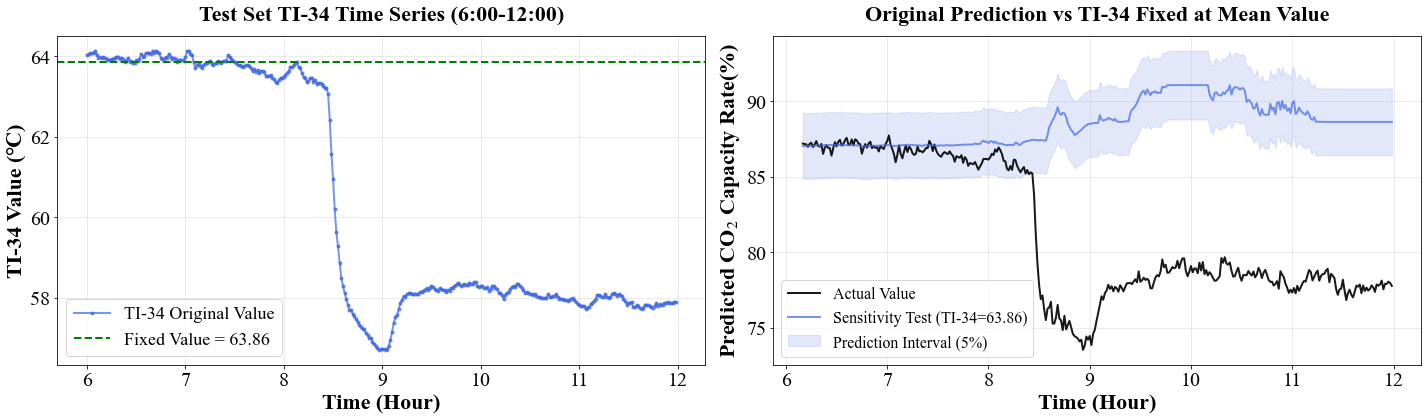

✓ TI-34 sensitivity-analysis comparison chart saved: sensitivity_analysis_TI34_comparison.png


In [56]:
# Step 5: Visual comparison (TI-34 time series + sensitivity prediction side-by-side)
print("\n" + "="*80)
print("Plot TI-34 sensitivity-analysis comparison")
print("="*80)

# Time axis after sliding-window shift
time_windows = np.arange(len(y_pred_original)) / 60 + start_hour + 10/60  # +10 min due to window lag

# Uncertainty interval (±2.5%)
uncertainty_ratio = 0.025
sensitivity_pred_lower = y_pred_sensitivity * (1 - uncertainty_ratio)
sensitivity_pred_upper = y_pred_sensitivity * (1 + uncertainty_ratio)

# Time axis in hours
time_minutes = np.arange(len(ti34_values))
time_hours = time_minutes / 60 + start_hour

# Two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Left: TI-34 time series
ax_left = axes[0]
ax_left.plot(time_hours, ti34_values, 'o-', linewidth=2, markersize=3, alpha=0.7, color='royalblue', label='TI-34 Original Value')
ax_left.axhline(ti34_fixed_value, color='green', linestyle='--', linewidth=2, label=f'Fixed Value = {ti34_fixed_value:.2f}')
ax_left.set_xlabel('Time (Hour)', fontsize=22, fontweight='bold')
ax_left.set_ylabel('TI-34 Value (℃)', fontsize=22, fontweight='bold')
ax_left.set_title('Test Set TI-34 Time Series (6:00-12:00)', fontsize=22, fontweight='bold', pad=15)
ax_left.set_xticks(range(start_hour, end_hour + 1))
ax_left.tick_params(axis='both', labelsize=20)
ax_left.legend(fontsize=18, loc='best')
ax_left.grid(True, alpha=0.3)

# Right: original prediction vs sensitivity prediction
ax_right = axes[1]
ax_right.plot(time_windows, y_test_6_12_windows, '-', label='Actual Value',
         linewidth=2, alpha=0.9, color='black')
ax_right.plot(time_windows, y_pred_sensitivity, '-', label=f'Sensitivity Test (TI-34={ti34_fixed_value:.2f})',
         linewidth=2, markersize=3, alpha=0.7, color='royalblue')
ax_right.fill_between(time_windows, sensitivity_pred_lower, sensitivity_pred_upper,
                 color='royalblue', alpha=0.15, label='Prediction Interval (5%)')
ax_right.set_xlabel('Time (Hour)', fontsize=22, fontweight='bold')
ax_right.set_ylabel('Predicted CO$_2$ Capacity Rate(%)', fontsize=22, fontweight='bold')
ax_right.set_title('Original Prediction vs TI-34 Fixed at Mean Value', fontsize=22, fontweight='bold', pad=15)
ax_right.set_xticks(range(start_hour, end_hour + 1))
ax_right.tick_params(axis='both', labelsize=20)
ax_right.legend(fontsize=16, loc='best')
ax_right.grid(True, alpha=0.3)
from matplotlib.ticker import FuncFormatter

ax_right.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'{y*100:.0f}')
)

plt.tight_layout()
plt.savefig('sensitivity_analysis_TI34_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"✓ TI-34 sensitivity-analysis comparison chart saved: sensitivity_analysis_TI34_comparison.png")

In [57]:
# Step 6: Compute performance comparison
print("\n" + "="*80)
print("Performance comparison")
print("="*80)

# Original prediction metrics
r2_original = r2_score(y_test_6_12_windows, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_test_6_12_windows, y_pred_original))
mae_original = mean_absolute_error(y_test_6_12_windows, y_pred_original)

# Sensitivity-test metrics
r2_sensitivity = r2_score(y_test_6_12_windows, y_pred_sensitivity)
rmse_sensitivity = np.sqrt(mean_squared_error(y_test_6_12_windows, y_pred_sensitivity))
mae_sensitivity = mean_absolute_error(y_test_6_12_windows, y_pred_sensitivity)

print(f"\n[Original Prediction Performance (TI-34 varying)]")
print(f"  • R²: {r2_original:.4f}")
print(f"  • RMSE: {rmse_original:.6f}")
print(f"  • MAE: {mae_original:.6f}")

print(f"\n[Sensitivity-Test Performance (TI-34={ti34_fixed_value:.1f})]")
print(f"  • R²: {r2_sensitivity:.4f}")
print(f"  • RMSE: {rmse_sensitivity:.6f}")
print(f"  • MAE: {mae_sensitivity:.6f}")

print(f"\n[Performance Change]")
print(f"  • ΔR²: {r2_sensitivity - r2_original:.4f} ({((r2_sensitivity - r2_original) / r2_original * 100):.2f}%)")
print(f"  • ΔRMSE: {rmse_sensitivity - rmse_original:.6f} ({((rmse_sensitivity - rmse_original) / rmse_original * 100):.2f}%)")
print(f"  • ΔMAE: {mae_sensitivity - mae_original:.6f} ({((mae_sensitivity - mae_original) / mae_original * 100):.2f}%)")

print(f"\n[Sensitivity Conclusion]")
if abs(pred_diff.mean()) < 0.001:
    print(f"  ✓ TI-34 has a small impact (mean difference < 0.001)")
elif abs(pred_diff.mean()) < 0.01:
    print(f"  • TI-34 has a moderate impact (mean difference ≈ {abs(pred_diff.mean()):.4f})")
else:
    print(f"  ⚠ TI-34 has a large impact (mean difference = {abs(pred_diff.mean()):.4f})")

print(f"  • Relative impact: {relative_impact:.2f}%")
print(f"  • Model sensitivity to TI-34: {'High' if relative_impact > 5 else 'Moderate' if relative_impact > 1 else 'Low'}")


Performance comparison

[Original Prediction Performance (TI-34 varying)]
  • R²: 0.8452
  • RMSE: 0.017561
  • MAE: 0.011295

[Sensitivity-Test Performance (TI-34=63.9)]
  • R²: -3.2085
  • RMSE: 0.091555
  • MAE: 0.073323

[Performance Change]
  • ΔR²: -4.0536 (-479.63%)
  • ΔRMSE: 0.073994 (421.35%)
  • ΔMAE: 0.062028 (549.16%)

[Sensitivity Conclusion]
  ⚠ TI-34 has a large impact (mean difference = 0.0641)
  • Relative impact: 7.86%
  • Model sensitivity to TI-34: High


## Sensitivity Analysis: Impact of TI-28 on the Test Set

**Objective:**
- Analyze the impact of feature TI-28 on model predictions
- Time range: 6:00 to 12:00 in the test set (6 hours = 360 minutes)
- Method: replace TI-28 with its 6:00-8:00 mean value and observe prediction changes

**Steps:**
1. Extract test-set data from 6:00 to 12:00
2. Plot TI-28 original-value time series
3. Compute TI-28 statistics (mean, std, etc.)
4. Compute TI-28 mean from 6:00-8:00 and replace all TI-28 values
5. Rebuild sliding windows and predict
6. Compare original predictions vs sensitivity-test predictions

In [58]:
# Step 1: Extract TI-28 data and compute statistics
print("="*80)
print("Sensitivity analysis: impact of TI-28 on prediction")
print("="*80)

print(f"\n[Time Range]")
print(f"  • Analysis window: {start_hour}:00 - {end_hour}:00")
print(f"  • Corresponding index: minute {start_min} to {end_min}")
print(f"  • TI-28 index in selected features: {selected_features.index('TI-28')}")

# Extract TI-28 values (using extracted 6:00-12:00 data)
ti28_values = X_test_6_12_raw['TI-28'].values
ti28_mean = ti28_values.mean()
ti28_std = ti28_values.std()
# Use mean value from 6:00-8:00 as fixed value for sensitivity analysis
ti28_values_6_8 = X_test_raw.iloc[6*60:8*60]['TI-28'].values
ti28_fixed_value = ti28_values_6_8.mean()

print(f"\n[TI-28 Statistics (6:00-12:00)]")
print(f"  • Sample count: {len(ti28_values)}")
print(f"  • Mean: {ti28_mean:.6f}")
print(f"  • Fixed value for sensitivity test (mean from 6:00-8:00): {ti28_fixed_value:.6f}")
print(f"  • Std: {ti28_std:.6f}")
print(f"  • Max: {ti28_values.max():.6f}")
print(f"  • Min: {ti28_values.min():.6f}")

Sensitivity analysis: impact of TI-28 on prediction

[Time Range]
  • Analysis window: 6:00 - 12:00
  • Corresponding index: minute 360 to 720
  • TI-28 index in selected features: 9

[TI-28 Statistics (6:00-12:00)]
  • Sample count: 360
  • Mean: 89.986295
  • Fixed value for sensitivity test (mean from 6:00-8:00): 89.676984
  • Std: 0.547155
  • Max: 91.900002
  • Min: 88.415932



Plot TI-28 original values (6:00-12:00)


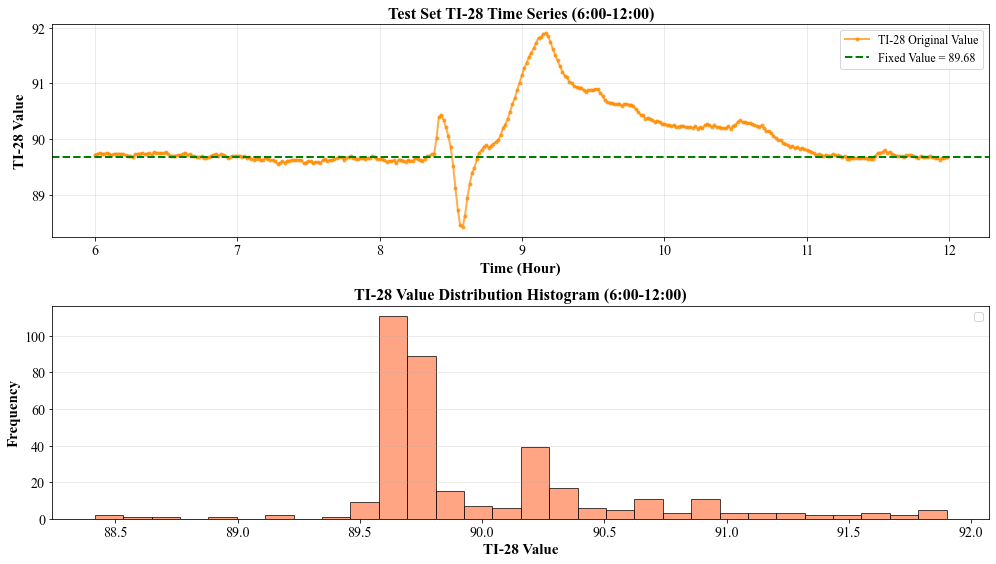

✓ TI-28 original-value chart saved: sensitivity_TI28_original_values.png


In [59]:
# Step 2: Plot TI-28 original-value time series
print("\n" + "="*80)
print("Plot TI-28 original values (6:00-12:00)")
print("="*80)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: TI-28 time series
ax1 = axes[0]
ax1.plot(time_hours, ti28_values, 'o-', linewidth=2, markersize=3, alpha=0.7, label='TI-28 Original Value', color='darkorange')
ax1.axhline(ti28_fixed_value, color='green', linestyle='--', linewidth=2, label=f'Fixed Value = {ti28_fixed_value:.2f}')
ax1.set_xlabel('Time (Hour)', fontsize=15, fontweight='bold')
ax1.set_ylabel('TI-28 Value', fontsize=15, fontweight='bold')
ax1.set_title('Test Set TI-28 Time Series (6:00-12:00)', fontsize=16, fontweight='bold')
ax1.set_xticks(range(start_hour, end_hour + 1))
ax1.tick_params(axis='both', labelsize=14)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: TI-28 histogram
ax2 = axes[1]
ax2.hist(ti28_values, bins=30, color='coral', edgecolor='black', alpha=0.7)
ax2.set_xlabel('TI-28 Value', fontsize=15, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=15, fontweight='bold')
ax2.set_title('TI-28 Value Distribution Histogram (6:00-12:00)', fontsize=16, fontweight='bold')
ax2.tick_params(axis='both', labelsize=14)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sensitivity_TI28_original_values.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ TI-28 original-value chart saved: sensitivity_TI28_original_values.png")

In [60]:
# Step 3: Build TI-28 sensitivity-test dataset (replace TI-28 with fixed value)
print("\n" + "="*80)
print("Build TI-28 sensitivity-test dataset")
print("="*80)

# Copy original data
X_test_6_12_sensitivity_ti28 = X_test_6_12_raw.copy()

# Replace TI-28 column with fixed value
X_test_6_12_sensitivity_ti28['TI-28'] = ti28_fixed_value

print(f"\n[Data Replacement]")
print(f"  • Original TI-28 range: [{ti28_values.min():.6f}, {ti28_values.max():.6f}]")
print(f"  • Replaced TI-28 value: {ti28_fixed_value:.6f} (constant)")
print(f"  • Other features: unchanged")

# Verify replacement
print(f"\n[Replacement Check]")
print(f"  • TI-28 unique count (original): {X_test_6_12_raw['TI-28'].nunique()}")
print(f"  • TI-28 unique count (replaced): {X_test_6_12_sensitivity_ti28['TI-28'].nunique()}")
print(f"  • Replaced TI-28 values: {X_test_6_12_sensitivity_ti28['TI-28'].unique()}")

# Build sliding windows (sensitivity-test data)
X_test_6_12_sensitivity_ti28_windows, _ = create_sliding_windows(
    X_test_6_12_sensitivity_ti28, y_test_6_12_raw, window_size=10
)

print(f"\n[Sliding-Window Data]")
print(f"  • Original window count: {len(X_test_6_12_windows)}")
print(f"  • TI-28 sensitivity-test window count: {len(X_test_6_12_sensitivity_ti28_windows)}")
print(f"  • Window feature dimension: {X_test_6_12_sensitivity_ti28_windows.shape[1]} (10 time steps × {len(selected_features)} features)")


Build TI-28 sensitivity-test dataset

[Data Replacement]
  • Original TI-28 range: [88.415932, 91.900002]
  • Replaced TI-28 value: 89.676984 (constant)
  • Other features: unchanged

[Replacement Check]
  • TI-28 unique count (original): 306
  • TI-28 unique count (replaced): 1
  • Replaced TI-28 values: [89.67698441]

[Sliding-Window Data]
  • Original window count: 350
  • TI-28 sensitivity-test window count: 350
  • Window feature dimension: 110 (10 time steps × 11 features)


In [61]:
# Step 4: Model prediction comparison (TI-28 sensitivity analysis)
print("\n" + "="*80)
print("Model prediction comparison (TI-28)")
print("="*80)

# Rebuild original sliding windows to guarantee matching length
X_test_6_12_windows_ti28, y_test_6_12_windows_ti28 = create_sliding_windows(
    X_test_6_12_raw, y_test_6_12_raw, window_size=10
)

# TI-28 sensitivity-test prediction
y_pred_sensitivity_ti28 = rf_model.predict(X_test_6_12_sensitivity_ti28_windows)

# Original-data prediction (same length as sensitivity-test data)
y_pred_original_ti28 = rf_model.predict(X_test_6_12_windows_ti28)

# Prediction difference (sensitivity - original)
pred_diff_ti28 = y_pred_sensitivity_ti28 - y_pred_original_ti28
abs_pred_diff_ti28 = np.abs(pred_diff_ti28)

print(f"\n[Prediction Comparison]")
print(f"  • Number of samples: {len(y_pred_original_ti28)}")
print(f"\nOriginal prediction:")
print(f"  • Mean: {y_pred_original_ti28.mean():.6f}")
print(f"  • Std: {y_pred_original_ti28.std():.6f}")
print(f"  • Range: [{y_pred_original_ti28.min():.6f}, {y_pred_original_ti28.max():.6f}]")

print(f"\nTI-28 sensitivity prediction (TI-28={ti28_fixed_value:.2f}):")
print(f"  • Mean: {y_pred_sensitivity_ti28.mean():.6f}")
print(f"  • Std: {y_pred_sensitivity_ti28.std():.6f}")
print(f"  • Range: [{y_pred_sensitivity_ti28.min():.6f}, {y_pred_sensitivity_ti28.max():.6f}]")

print(f"\nPrediction difference (TI-28 sensitivity - original):")
print(f"  • Mean difference: {pred_diff_ti28.mean():.6f}")
print(f"  • Mean absolute difference: {abs_pred_diff_ti28.mean():.6f}")
print(f"  • Difference std: {pred_diff_ti28.std():.6f}")
print(f"  • Maximum positive difference: {pred_diff_ti28.max():.6f}")
print(f"  • Maximum negative difference: {pred_diff_ti28.min():.6f}")

# Relative impact (%)
relative_impact_ti28 = (abs_pred_diff_ti28.mean() / y_pred_original_ti28.mean()) * 100
print(f"\n[TI-28 Sensitivity Indicator]")
print(f"  • Relative impact: {relative_impact_ti28:.2f}%")
print(f"  • Interpretation: fixing TI-28 at {ti28_fixed_value:.2f} changes prediction by {relative_impact_ti28:.2f}% on average")


Model prediction comparison (TI-28)

[Prediction Comparison]
  • Number of samples: 350

Original prediction:
  • Mean: 0.821040
  • Std: 0.042566
  • Range: [0.674037, 0.877402]

TI-28 sensitivity prediction (TI-28=89.68):
  • Mean: 0.820788
  • Std: 0.040740
  • Range: [0.786367, 0.877521]

Prediction difference (TI-28 sensitivity - original):
  • Mean difference: -0.000252
  • Mean absolute difference: 0.005073
  • Difference std: 0.013271
  • Maximum positive difference: 0.114376
  • Maximum negative difference: -0.007274

[TI-28 Sensitivity Indicator]
  • Relative impact: 0.62%
  • Interpretation: fixing TI-28 at 89.68 changes prediction by 0.62% on average



Plot TI-28 sensitivity-analysis comparison


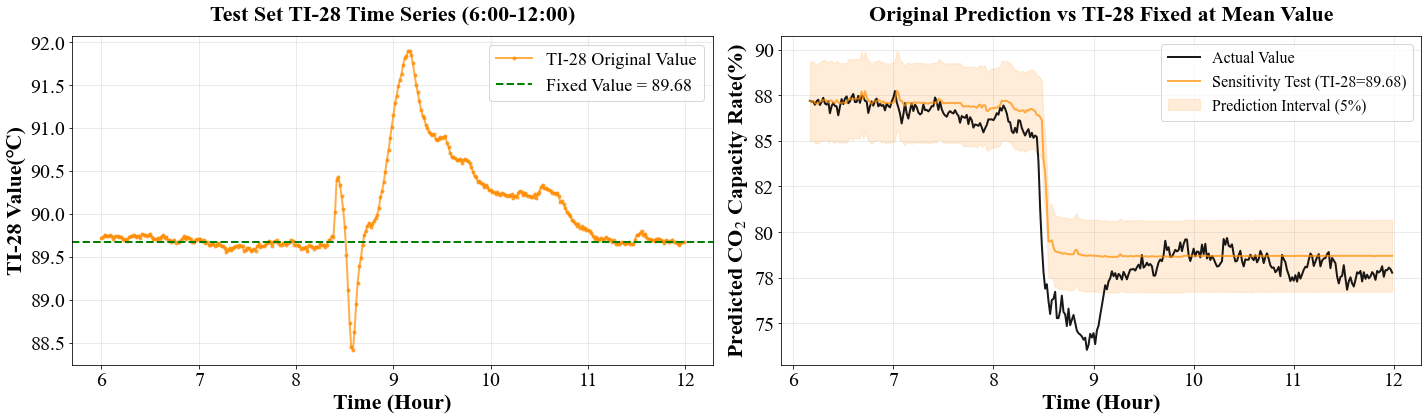

In [62]:
# Step 5: Visual comparison (TI-28 time series + sensitivity prediction side-by-side)
print("\n" + "="*80)
print("Plot TI-28 sensitivity-analysis comparison")
print("="*80)

# Create time axis (after sliding-window shift)
time_windows_ti28 = np.arange(len(y_pred_original_ti28)) / 60 + start_hour + 10/60  # +10 min due to window lag

# Uncertainty interval (±2.5%)
uncertainty_ratio = 0.025
ti28_sensitivity_pred_lower = y_pred_sensitivity_ti28 * (1 - uncertainty_ratio)
ti28_sensitivity_pred_upper = y_pred_sensitivity_ti28 * (1 + uncertainty_ratio)

# Create time axis (minutes)
time_minutes = np.arange(len(ti28_values))
time_hours = time_minutes / 60 + start_hour  # Convert to hours, starting at 6:00

# Create two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Left: TI-28 time series
ax_left = axes[0]
ax_left.plot(time_hours, ti28_values, 'o-', linewidth=2, markersize=3, alpha=0.7, color='darkorange', label='TI-28 Original Value')
ax_left.axhline(ti28_fixed_value, color='green', linestyle='--', linewidth=2, label=f'Fixed Value = {ti28_fixed_value:.2f}')
ax_left.set_xlabel('Time (Hour)', fontsize=22, fontweight='bold')
ax_left.set_ylabel('TI-28 Value(℃)', fontsize=22, fontweight='bold')
ax_left.set_title('Test Set TI-28 Time Series (6:00-12:00)', fontsize=22, fontweight='bold', pad=15)
ax_left.set_xticks(range(start_hour, end_hour + 1))
ax_left.tick_params(axis='both', labelsize=20)
ax_left.legend(fontsize=18, loc='best')
ax_left.grid(True, alpha=0.3)

# Right: original prediction vs sensitivity prediction
ax_right = axes[1]
ax_right.plot(time_windows_ti28, y_test_6_12_windows_ti28, '-', label='Actual Value', 
         linewidth=2, alpha=0.9, color='black')
ax_right.plot(time_windows_ti28, y_pred_sensitivity_ti28, '-', label=f'Sensitivity Test (TI-28={ti28_fixed_value:.2f})', 
         linewidth=2, markersize=3, alpha=0.7, color='darkorange')
ax_right.fill_between(time_windows_ti28, ti28_sensitivity_pred_lower, ti28_sensitivity_pred_upper, 
                 color='darkorange', alpha=0.15, label='Prediction Interval (5%)')
ax_right.set_xlabel('Time (Hour)', fontsize=22, fontweight='bold')
ax_right.set_ylabel('Predicted CO$_2$ Capacity Rate(%)', fontsize=22, fontweight='bold')
ax_right.set_title('Original Prediction vs TI-28 Fixed at Mean Value', fontsize=22, fontweight='bold', pad=15)
ax_right.set_xticks(range(start_hour, end_hour + 1))
ax_right.tick_params(axis='both', labelsize=20)
ax_right.legend(fontsize=16, loc='best')
ax_right.grid(True, alpha=0.3)

from matplotlib.ticker import FuncFormatter

ax_right.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'{y*100:.0f}')
)
plt.tight_layout()
plt.savefig('sensitivity_analysis_TI28_comparison.png', dpi=200, bbox_inches='tight')

ax_right.grid(True, alpha=0.3)
plt.tight_layout()

In [63]:
# Step 6: Compute TI-28 performance comparison
print("\n" + "="*80)
print("TI-28 performance comparison")
print("="*80)

# TI-28 sensitivity-test metrics
r2_sensitivity_ti28 = r2_score(y_test_6_12_windows_ti28, y_pred_sensitivity_ti28)
rmse_sensitivity_ti28 = np.sqrt(mean_squared_error(y_test_6_12_windows_ti28, y_pred_sensitivity_ti28))
mae_sensitivity_ti28 = mean_absolute_error(y_test_6_12_windows_ti28, y_pred_sensitivity_ti28)

# Original prediction metrics
r2_original_ti28 = r2_score(y_test_6_12_windows_ti28, y_pred_original_ti28)
rmse_original_ti28 = np.sqrt(mean_squared_error(y_test_6_12_windows_ti28, y_pred_original_ti28))
mae_original_ti28 = mean_absolute_error(y_test_6_12_windows_ti28, y_pred_original_ti28)

print(f"\n[Original Prediction Performance (TI-28 varying)]")
print(f"  • R²: {r2_original_ti28:.4f}")
print(f"  • RMSE: {rmse_original_ti28:.6f}")
print(f"  • MAE: {mae_original_ti28:.6f}")

print(f"\n[TI-28 Sensitivity-Test Performance (TI-28={ti28_fixed_value:.2f})]")
print(f"  • R²: {r2_sensitivity_ti28:.4f}")
print(f"  • RMSE: {rmse_sensitivity_ti28:.6f}")
print(f"  • MAE: {mae_sensitivity_ti28:.6f}")

print(f"\n[Performance Change]")
print(f"  • ΔR²: {r2_sensitivity_ti28 - r2_original_ti28:.4f} ({((r2_sensitivity_ti28 - r2_original_ti28) / r2_original_ti28 * 100):.2f}%)")
print(f"  • ΔRMSE: {rmse_sensitivity_ti28 - rmse_original_ti28:.6f} ({((rmse_sensitivity_ti28 - rmse_original_ti28) / rmse_original_ti28 * 100):.2f}%)")
print(f"  • ΔMAE: {mae_sensitivity_ti28 - mae_original_ti28:.6f} ({((mae_sensitivity_ti28 - mae_original_ti28) / mae_original_ti28 * 100):.2f}%)")

print(f"\n[TI-28 Sensitivity Conclusion]")
if abs(pred_diff_ti28.mean()) < 0.001:
    print(f"  ✓ TI-28 has a small impact (mean difference < 0.001)")
elif abs(pred_diff_ti28.mean()) < 0.01:
    print(f"  • TI-28 has a moderate impact (mean difference ≈ {abs(pred_diff_ti28.mean()):.4f})")
else:
    print(f"  ⚠ TI-28 has a large impact (mean difference = {abs(pred_diff_ti28.mean()):.4f})")


TI-28 performance comparison

[Original Prediction Performance (TI-28 varying)]
  • R²: 0.8452
  • RMSE: 0.017561
  • MAE: 0.011295

[TI-28 Sensitivity-Test Performance (TI-28=89.68)]
  • R²: 0.8800
  • RMSE: 0.015462
  • MAE: 0.009703

[Performance Change]
  • ΔR²: 0.0348 (4.12%)
  • ΔRMSE: -0.002099 (-11.95%)
  • ΔMAE: -0.001592 (-14.10%)

[TI-28 Sensitivity Conclusion]
  ✓ TI-28 has a small impact (mean difference < 0.001)


## Sensitivity Analysis: Impact of Level Reboiler on the Test Set

**Objective:**
- Analyze the impact of feature Level Reboiler on model predictions
- Time range: 6:00 to 12:00 in the test set (6 hours = 360 minutes)
- Method: replace Level Reboiler with its 6:00-8:00 mean value and observe prediction changes

**Steps:**
1. Extract test-set data from 6:00 to 12:00
2. Plot Level Reboiler original-value time series
3. Compute Level Reboiler statistics (mean, std, etc.)
4. Compute Level Reboiler mean from 6:00-8:00 and replace all values
5. Rebuild sliding windows and predict
6. Compare original predictions vs sensitivity-test predictions

In [64]:
# Step 1: Extract Level Reboiler data and compute statistics
print("="*80)
print("Sensitivity analysis: impact of Level Reboiler on prediction")
print("="*80)

print(f"\n[Time Range]")
print(f"  • Analysis window: {start_hour}:00 - {end_hour}:00")
print(f"  • Corresponding index: minute {start_min} to {end_min}")
print(f"  • Level Reboiler index in selected features: {selected_features.index('Level Reboiler')}")

# Extract Level Reboiler values (using extracted 6:00-12:00 data)
level_reboiler_values = X_test_6_12_raw['Level Reboiler'].values
level_reboiler_mean = level_reboiler_values.mean()
level_reboiler_std = level_reboiler_values.std()

# Use mean value from 6:00-8:00 as fixed value for sensitivity analysis
level_reboiler_values_6_8 = X_test_raw.iloc[6*60:8*60]['Level Reboiler'].values
level_reboiler_fixed_value = level_reboiler_values_6_8.mean()

print(f"\n[Level Reboiler Statistics (6:00-12:00)]")
print(f"  • Sample count: {len(level_reboiler_values)}")
print(f"  • Mean: {level_reboiler_mean:.6f}")
print(f"  • Fixed value for sensitivity test (mean from 6:00-8:00): {level_reboiler_fixed_value:.6f}")
print(f"  • Std: {level_reboiler_std:.6f}")
print(f"  • Max: {level_reboiler_values.max():.6f}")
print(f"  • Min: {level_reboiler_values.min():.6f}")
print(f"  • Coefficient of variation: {(level_reboiler_std / level_reboiler_mean * 100):.2f}%")

Sensitivity analysis: impact of Level Reboiler on prediction

[Time Range]
  • Analysis window: 6:00 - 12:00
  • Corresponding index: minute 360 to 720
  • Level Reboiler index in selected features: 10

[Level Reboiler Statistics (6:00-12:00)]
  • Sample count: 360
  • Mean: 71.713622
  • Fixed value for sensitivity test (mean from 6:00-8:00): 70.602127
  • Std: 0.982941
  • Max: 73.198975
  • Min: 70.477013
  • Coefficient of variation: 1.37%



Plot Level Reboiler original values (6:00-12:00)


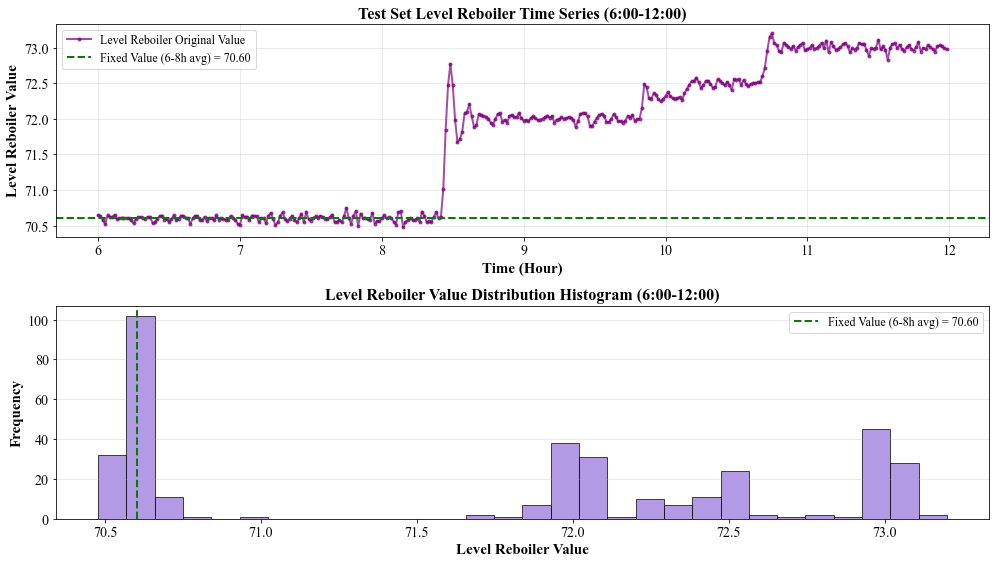

✓ Level Reboiler original values chart saved as: sensitivity_LevelReboiler_original_values.png


In [65]:
# Step 2: Plot Level Reboiler original-value time series
print("\n" + "="*80)
print("Plot Level Reboiler original values (6:00-12:00)")
print("="*80)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Level Reboiler time series
ax1 = axes[0]
ax1.plot(time_hours, level_reboiler_values, 'o-', linewidth=2, markersize=3, alpha=0.7, 
         label='Level Reboiler Original Value', color='purple')
ax1.axhline(level_reboiler_fixed_value, color='green', linestyle='--', linewidth=2, 
            label=f'Fixed Value (6-8h avg) = {level_reboiler_fixed_value:.2f}')
ax1.set_xlabel('Time (Hour)', fontsize=15, fontweight='bold')
ax1.set_ylabel('Level Reboiler Value', fontsize=15, fontweight='bold')
ax1.set_title('Test Set Level Reboiler Time Series (6:00-12:00)', fontsize=16, fontweight='bold')
ax1.set_xticks(range(start_hour, end_hour + 1))
ax1.tick_params(axis='both', labelsize=14)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Level Reboiler histogram
ax2 = axes[1]
ax2.hist(level_reboiler_values, bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
ax2.axvline(level_reboiler_fixed_value, color='green', linestyle='--', linewidth=2, 
            label=f'Fixed Value (6-8h avg) = {level_reboiler_fixed_value:.2f}')
ax2.set_xlabel('Level Reboiler Value', fontsize=15, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=15, fontweight='bold')
ax2.set_title('Level Reboiler Value Distribution Histogram (6:00-12:00)', fontsize=16, fontweight='bold')
ax2.tick_params(axis='both', labelsize=14)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sensitivity_LevelReboiler_original_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Level Reboiler original values chart saved as: sensitivity_LevelReboiler_original_values.png")

In [66]:
# Step 3: Build Level Reboiler sensitivity-test dataset (replace with 6:00-8:00 mean)
print("\n" + "="*80)
print("Build Level Reboiler sensitivity-test dataset")
print("="*80)

# Copy original data
X_test_6_12_sensitivity_lr = X_test_6_12_raw.copy()

# Replace Level Reboiler column with fixed value
X_test_6_12_sensitivity_lr['Level Reboiler'] = level_reboiler_fixed_value

print(f"\n[Data Replacement]")
print(f"  • Original Level Reboiler range: [{level_reboiler_values.min():.6f}, {level_reboiler_values.max():.6f}]")
print(f"  • Replaced Level Reboiler value: {level_reboiler_fixed_value:.6f} (constant, from 6:00-8:00 mean)")
print(f"  • Other features: unchanged")

# Verify replacement
print(f"\n[Replacement Check]")
print(f"  • Level Reboiler unique count (original): {X_test_6_12_raw['Level Reboiler'].nunique()}")
print(f"  • Level Reboiler unique count (replaced): {X_test_6_12_sensitivity_lr['Level Reboiler'].nunique()}")
print(f"  • Replaced Level Reboiler value: {X_test_6_12_sensitivity_lr['Level Reboiler'].unique()}")

# Build sliding windows (sensitivity-test data)
X_test_6_12_sensitivity_lr_windows, _ = create_sliding_windows(
    X_test_6_12_sensitivity_lr, y_test_6_12_raw, window_size=10
)

print(f"\n[Sliding-Window Data]")
print(f"  • Original window count: {len(X_test_6_12_windows)}")
print(f"  • Level Reboiler sensitivity-test window count: {len(X_test_6_12_sensitivity_lr_windows)}")
print(f"  • Window feature dimension: {X_test_6_12_sensitivity_lr_windows.shape[1]} (10 time steps × {len(selected_features)} features)")


Build Level Reboiler sensitivity-test dataset

[Data Replacement]
  • Original Level Reboiler range: [70.477013, 73.198975]
  • Replaced Level Reboiler value: 70.602127 (constant, from 6:00-8:00 mean)
  • Other features: unchanged

[Replacement Check]
  • Level Reboiler unique count (original): 356
  • Level Reboiler unique count (replaced): 1
  • Replaced Level Reboiler value: [70.60212676]

[Sliding-Window Data]
  • Original window count: 350
  • Level Reboiler sensitivity-test window count: 350
  • Window feature dimension: 110 (10 time steps × 11 features)


In [67]:
# Step 4: Model prediction comparison (Level Reboiler sensitivity analysis)
print("\n" + "="*80)
print("Model prediction comparison (Level Reboiler)")
print("="*80)

# Rebuild original sliding windows to guarantee matching length
X_test_6_12_windows_lr, y_test_6_12_windows_lr = create_sliding_windows(
    X_test_6_12_raw, y_test_6_12_raw, window_size=10
)

# Level Reboiler sensitivity-test prediction
y_pred_sensitivity_lr = rf_model.predict(X_test_6_12_sensitivity_lr_windows)

# Original-data prediction (same length as sensitivity-test data)
y_pred_original_lr = rf_model.predict(X_test_6_12_windows_lr)

# Prediction difference (sensitivity - original)
pred_diff_lr = y_pred_sensitivity_lr - y_pred_original_lr
abs_pred_diff_lr = np.abs(pred_diff_lr)

print(f"\n[Prediction Comparison]")
print(f"  • Number of samples: {len(y_pred_original_lr)}")
print(f"\nOriginal prediction:")
print(f"  • Mean: {y_pred_original_lr.mean():.6f}")
print(f"  • Std: {y_pred_original_lr.std():.6f}")
print(f"  • Range: [{y_pred_original_lr.min():.6f}, {y_pred_original_lr.max():.6f}]")

print(f"\nLevel Reboiler sensitivity prediction (Level Reboiler={level_reboiler_fixed_value:.2f}):")
print(f"  • Mean: {y_pred_sensitivity_lr.mean():.6f}")
print(f"  • Std: {y_pred_sensitivity_lr.std():.6f}")
print(f"  • Range: [{y_pred_sensitivity_lr.min():.6f}, {y_pred_sensitivity_lr.max():.6f}]")

print(f"\nPrediction difference (Level Reboiler sensitivity - original):")
print(f"  • Mean difference: {pred_diff_lr.mean():.6f}")
print(f"  • Mean absolute difference: {abs_pred_diff_lr.mean():.6f}")
print(f"  • Difference std: {pred_diff_lr.std():.6f}")
print(f"  • Maximum positive difference: {pred_diff_lr.max():.6f}")
print(f"  • Maximum negative difference: {pred_diff_lr.min():.6f}")

# Relative impact (%)
relative_impact_lr = (abs_pred_diff_lr.mean() / y_pred_original_lr.mean()) * 100
print(f"\n[Level Reboiler Sensitivity Indicator]")
print(f"  • Relative impact: {relative_impact_lr:.2f}%")
print(f"  • Interpretation: fixing Level Reboiler at {level_reboiler_fixed_value:.2f} (6:00-8:00 mean) changes prediction by {relative_impact_lr:.2f}% on average")


Model prediction comparison (Level Reboiler)

[Prediction Comparison]
  • Number of samples: 350

Original prediction:
  • Mean: 0.821040
  • Std: 0.042566
  • Range: [0.674037, 0.877402]

Level Reboiler sensitivity prediction (Level Reboiler=70.60):
  • Mean: 0.807083
  • Std: 0.053131
  • Range: [0.672018, 0.877402]

Prediction difference (Level Reboiler sensitivity - original):
  • Mean difference: -0.013956
  • Mean absolute difference: 0.013956
  • Difference std: 0.011935
  • Maximum positive difference: 0.000008
  • Maximum negative difference: -0.025964

[Level Reboiler Sensitivity Indicator]
  • Relative impact: 1.70%
  • Interpretation: fixing Level Reboiler at 70.60 (6:00-8:00 mean) changes prediction by 1.70% on average



Plot Level Reboiler sensitivity-analysis comparison


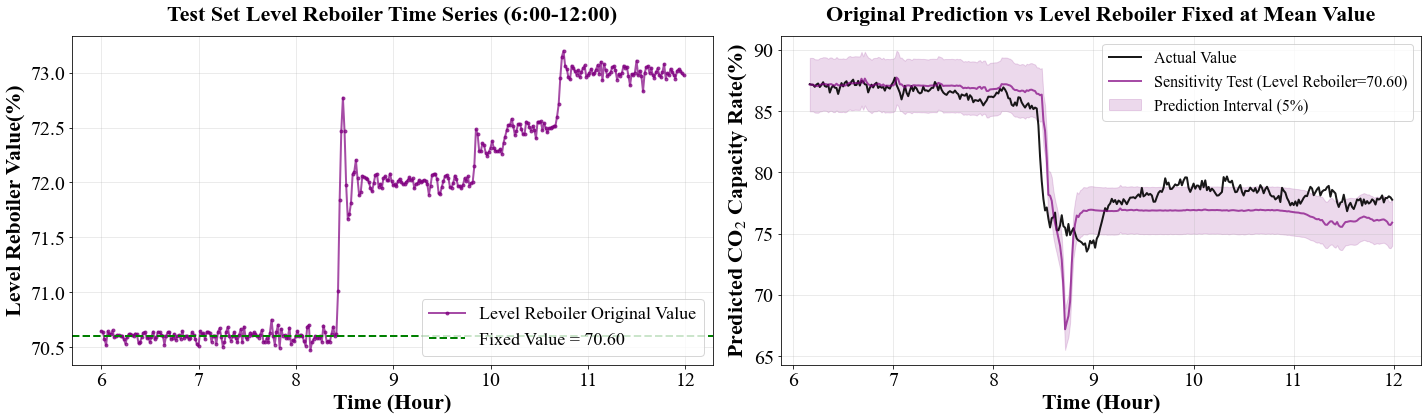

✓ Level Reboiler sensitivity-analysis comparison chart saved as: sensitivity_analysis_LevelReboiler_comparison.png


In [68]:
# Step 5: Visual comparison (Level Reboiler time series + sensitivity prediction side-by-side)
print("\n" + "="*80)
print("Plot Level Reboiler sensitivity-analysis comparison")
print("="*80)

# Create time axis (after sliding-window shift)
time_windows_lr = np.arange(len(y_pred_original_lr)) / 60 + start_hour + 10/60  # +10 min due to window lag

# Uncertainty interval (5%)
uncertainty_ratio = 0.025
lr_sensitivity_pred_lower = y_pred_sensitivity_lr * (1 - uncertainty_ratio)
lr_sensitivity_pred_upper = y_pred_sensitivity_lr * (1 + uncertainty_ratio)

# Create time axis (minutes)
time_minutes = np.arange(len(level_reboiler_values))
time_hours = time_minutes / 60 + start_hour  # Convert to hours, starting at 6:00

# Create two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Left: Level Reboiler time series
ax_left = axes[0]
ax_left.plot(time_hours, level_reboiler_values, 'o-', linewidth=2, markersize=3, alpha=0.7, color='purple', label='Level Reboiler Original Value')
ax_left.axhline(level_reboiler_fixed_value, color='green', linestyle='--', linewidth=2, label=f'Fixed Value = {level_reboiler_fixed_value:.2f}')
ax_left.set_xlabel('Time (Hour)', fontsize=22, fontweight='bold')
ax_left.set_ylabel('Level Reboiler Value(%)', fontsize=22, fontweight='bold')
ax_left.set_title('Test Set Level Reboiler Time Series (6:00-12:00)', fontsize=22, fontweight='bold', pad=15)
ax_left.set_xticks(range(start_hour, end_hour + 1))
ax_left.tick_params(axis='both', labelsize=20)
ax_left.legend(fontsize=18, loc='best')
ax_left.grid(True, alpha=0.3)

# Right: original prediction vs sensitivity prediction
ax_right = axes[1]
ax_right.plot(time_windows_lr, y_test_6_12_windows_lr, '-', label='Actual Value', 
         linewidth=2, alpha=0.9, color='black')
ax_right.plot(time_windows_lr, y_pred_sensitivity_lr, '-', label=f'Sensitivity Test (Level Reboiler={level_reboiler_fixed_value:.2f})', 
         linewidth=2, markersize=3, alpha=0.7, color='purple')
ax_right.fill_between(time_windows_lr, lr_sensitivity_pred_lower, lr_sensitivity_pred_upper, 
                 color='purple', alpha=0.15, label='Prediction Interval (5%)')
ax_right.set_xlabel('Time (Hour)', fontsize=22, fontweight='bold')
ax_right.set_ylabel('Predicted CO$_2$ Capacity Rate(%)', fontsize=22, fontweight='bold')
ax_right.set_title('Original Prediction vs Level Reboiler Fixed at Mean Value', fontsize=22, fontweight='bold', pad=15)
ax_right.set_xticks(range(start_hour, end_hour + 1))
ax_right.tick_params(axis='both', labelsize=20)
ax_right.legend(fontsize=16, loc='best')
ax_right.grid(True, alpha=0.3)
from matplotlib.ticker import FuncFormatter

ax_right.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'{y*100:.0f}')
)

plt.tight_layout()
plt.savefig('sensitivity_analysis_LevelReboiler_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"✓ Level Reboiler sensitivity-analysis comparison chart saved as: sensitivity_analysis_LevelReboiler_comparison.png")

In [69]:
# Step 6: Compute Level Reboiler performance comparison
print("\n" + "="*80)
print("Level Reboiler performance comparison")
print("="*80)

# Level Reboiler sensitivity-test metrics
r2_sensitivity_lr = r2_score(y_test_6_12_windows_lr, y_pred_sensitivity_lr)
rmse_sensitivity_lr = np.sqrt(mean_squared_error(y_test_6_12_windows_lr, y_pred_sensitivity_lr))
mae_sensitivity_lr = mean_absolute_error(y_test_6_12_windows_lr, y_pred_sensitivity_lr)

# Original prediction metrics
r2_original_lr = r2_score(y_test_6_12_windows_lr, y_pred_original_lr)
rmse_original_lr = np.sqrt(mean_squared_error(y_test_6_12_windows_lr, y_pred_original_lr))
mae_original_lr = mean_absolute_error(y_test_6_12_windows_lr, y_pred_original_lr)

print(f"\n[Original Prediction Performance (Level Reboiler varying)]")
print(f"  • R²: {r2_original_lr:.4f}")
print(f"  • RMSE: {rmse_original_lr:.6f}")
print(f"  • MAE: {mae_original_lr:.6f}")

print(f"\n[Level Reboiler Sensitivity-Test Performance (Level Reboiler={level_reboiler_fixed_value:.2f})]")
print(f"  • R²: {r2_sensitivity_lr:.4f}")
print(f"  • RMSE: {rmse_sensitivity_lr:.6f}")
print(f"  • MAE: {mae_sensitivity_lr:.6f}")

print(f"\n[Performance Change]")
print(f"  • ΔR²: {r2_sensitivity_lr - r2_original_lr:.4f} ({((r2_sensitivity_lr - r2_original_lr) / r2_original_lr * 100):.2f}%)")
print(f"  • ΔRMSE: {rmse_sensitivity_lr - rmse_original_lr:.6f} ({((rmse_sensitivity_lr - rmse_original_lr) / rmse_original_lr * 100):.2f}%)")
print(f"  • ΔMAE: {mae_sensitivity_lr - mae_original_lr:.6f} ({((mae_sensitivity_lr - mae_original_lr) / mae_original_lr * 100):.2f}%)")

print(f"\n[Level Reboiler Sensitivity Conclusion]")


Level Reboiler performance comparison

[Original Prediction Performance (Level Reboiler varying)]
  • R²: 0.8452
  • RMSE: 0.017561
  • MAE: 0.011295

[Level Reboiler Sensitivity-Test Performance (Level Reboiler=70.60)]
  • R²: 0.8421
  • RMSE: 0.017731
  • MAE: 0.013289

[Performance Change]
  • ΔR²: -0.0030 (-0.36%)
  • ΔRMSE: 0.000170 (0.97%)
  • ΔMAE: 0.001994 (17.66%)

[Level Reboiler Sensitivity Conclusion]


## Sensitivity Analysis: Impact of TI-24 on the Test Set

**Objective:**
- Analyze the impact of feature TI-24 on model predictions
- Time range: 6:00 to 12:00 in the test set (6 hours = 360 minutes)
- Method: replace TI-24 with its 6:00-8:00 mean value and observe prediction changes

**Steps:**
1. Extract test-set data from 6:00 to 12:00
2. Plot TI-24 original-value time series
3. Compute TI-24 statistics (mean, std, etc.)
4. Compute TI-24 mean from 6:00-8:00 and replace all TI-24 values
5. Rebuild sliding windows and predict
6. Compare original predictions vs sensitivity-test predictions

In [70]:
# Step 1: Extract TI-24 data and compute statistics
print("="*80)
print("Sensitivity analysis: impact of TI-24 on prediction")
print("="*80)

print(f"\n[Time Range]")
print(f"  • Analysis window: {start_hour}:00 - {end_hour}:00")
print(f"  • Corresponding index: minute {start_min} to {end_min}")
print(f"  • TI-24 index in selected features: {selected_features.index('TI-24')}")

# Extract TI-24 values (using extracted 6:00-12:00 data)
ti24_values = X_test_6_12_raw['TI-24'].values
ti24_mean = ti24_values.mean()
ti24_std = ti24_values.std()
# Use mean value from 6:00-8:00 as fixed value for sensitivity analysis
ti24_values_6_8 = X_test_raw.iloc[6*60:8*60]['TI-24'].values
ti24_fixed_value = ti24_values_6_8.mean()

print(f"\n[TI-24 Statistics (6:00-12:00)]")
print(f"  • Sample count: {len(ti24_values)}")
print(f"  • Mean: {ti24_mean:.6f}")
print(f"  • Fixed value for sensitivity test (mean from 6:00-8:00): {ti24_fixed_value:.6f}")
print(f"  • Std: {ti24_std:.6f}")
print(f"  • Max: {ti24_values.max():.6f}")
print(f"  • Min: {ti24_values.min():.6f}")
print(f"  • Coefficient of variation: {(ti24_std / ti24_mean * 100):.2f}%")

Sensitivity analysis: impact of TI-24 on prediction

[Time Range]
  • Analysis window: 6:00 - 12:00
  • Corresponding index: minute 360 to 720
  • TI-24 index in selected features: 8

[TI-24 Statistics (6:00-12:00)]
  • Sample count: 360
  • Mean: 42.121864
  • Fixed value for sensitivity test (mean from 6:00-8:00): 43.870364
  • Std: 1.592528
  • Max: 43.936161
  • Min: 40.319363
  • Coefficient of variation: 3.78%



Plot TI-24 original values (6:00-12:00)


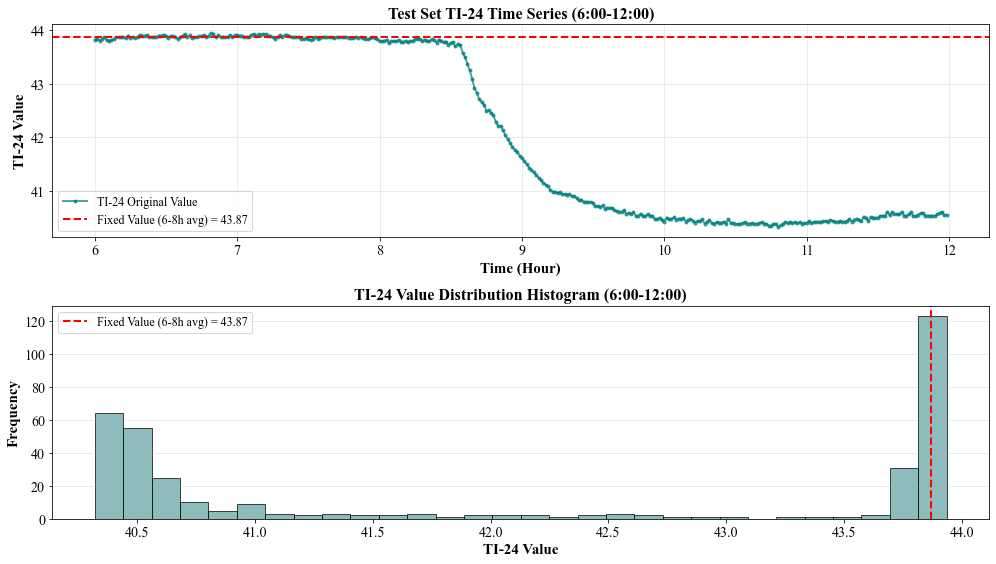

✓ TI-24 original-value chart saved: sensitivity_TI24_original_values.png


In [71]:
# Step 2: Plot TI-24 original-value time series
print("\n" + "="*80)
print("Plot TI-24 original values (6:00-12:00)")
print("="*80)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: TI-24 time series
ax1 = axes[0]
ax1.plot(time_hours, ti24_values, 'o-', linewidth=2, markersize=3, alpha=0.7,
         label='TI-24 Original Value', color='teal')
ax1.axhline(ti24_fixed_value, color='red', linestyle='--', linewidth=2,
            label=f'Fixed Value (6-8h avg) = {ti24_fixed_value:.2f}')
ax1.set_xlabel('Time (Hour)', fontsize=15, fontweight='bold')
ax1.set_ylabel('TI-24 Value', fontsize=15, fontweight='bold')
ax1.set_title('Test Set TI-24 Time Series (6:00-12:00)', fontsize=16, fontweight='bold')
ax1.set_xticks(range(start_hour, end_hour + 1))
ax1.tick_params(axis='both', labelsize=14)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: TI-24 histogram
ax2 = axes[1]
ax2.hist(ti24_values, bins=30, color='cadetblue', edgecolor='black', alpha=0.7)
ax2.axvline(ti24_fixed_value, color='red', linestyle='--', linewidth=2,
            label=f'Fixed Value (6-8h avg) = {ti24_fixed_value:.2f}')
ax2.set_xlabel('TI-24 Value', fontsize=15, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=15, fontweight='bold')
ax2.set_title('TI-24 Value Distribution Histogram (6:00-12:00)', fontsize=16, fontweight='bold')
ax2.tick_params(axis='both', labelsize=14)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sensitivity_TI24_original_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ TI-24 original-value chart saved: sensitivity_TI24_original_values.png")

In [72]:
# Step 3: Build TI-24 sensitivity-test dataset (replace TI-24 with 6:00-8:00 mean)
print("\n" + "="*80)
print("Build TI-24 sensitivity-test dataset")
print("="*80)

# Copy original data
X_test_6_12_sensitivity_ti24 = X_test_6_12_raw.copy()

# Replace TI-24 column with fixed value
X_test_6_12_sensitivity_ti24['TI-24'] = ti24_fixed_value

print(f"\n[Data Replacement]")
print(f"  • Original TI-24 range: [{ti24_values.min():.6f}, {ti24_values.max():.6f}]")
print(f"  • Replaced TI-24 value: {ti24_fixed_value:.6f} (constant, from 6:00-8:00 mean)")
print(f"  • Other features: unchanged")

# Verify replacement
print(f"\n[Replacement Check]")
print(f"  • TI-24 unique count (original): {X_test_6_12_raw['TI-24'].nunique()}")
print(f"  • TI-24 unique count (replaced): {X_test_6_12_sensitivity_ti24['TI-24'].nunique()}")
print(f"  • Replaced TI-24 values: {X_test_6_12_sensitivity_ti24['TI-24'].unique()}")

# Build sliding windows (sensitivity-test data)
X_test_6_12_sensitivity_ti24_windows, _ = create_sliding_windows(
    X_test_6_12_sensitivity_ti24, y_test_6_12_raw, window_size=10
)

print(f"\n[Sliding-Window Data]")
print(f"  • Original window count: {len(X_test_6_12_windows)}")
print(f"  • TI-24 sensitivity-test window count: {len(X_test_6_12_sensitivity_ti24_windows)}")
print(f"  • Window feature dimension: {X_test_6_12_sensitivity_ti24_windows.shape[1]} (10 time steps × {len(selected_features)} features)")


Build TI-24 sensitivity-test dataset

[Data Replacement]
  • Original TI-24 range: [40.319363, 43.936161]
  • Replaced TI-24 value: 43.870364 (constant, from 6:00-8:00 mean)
  • Other features: unchanged

[Replacement Check]
  • TI-24 unique count (original): 315
  • TI-24 unique count (replaced): 1
  • Replaced TI-24 values: [43.87036368]

[Sliding-Window Data]
  • Original window count: 350
  • TI-24 sensitivity-test window count: 350
  • Window feature dimension: 110 (10 time steps × 11 features)


In [73]:
# Step 4: Model prediction comparison (TI-24 sensitivity analysis)
print("\n" + "="*80)
print("Model prediction comparison (TI-24)")
print("="*80)

# Build original sliding windows and predictions (ensure matching length)
X_test_6_12_windows_ti24, y_test_6_12_windows_ti24 = create_sliding_windows(
    X_test_6_12_raw, y_test_6_12_raw, window_size=10
)
y_pred_original_ti24 = rf_model.predict(X_test_6_12_windows_ti24)
time_windows_ti24 = np.arange(len(y_pred_original_ti24)) / 60 + start_hour + 10/60  # +10 min due to window lag

# TI-24 sensitivity-test prediction
y_pred_sensitivity_ti24 = rf_model.predict(X_test_6_12_sensitivity_ti24_windows)

# Prediction difference (sensitivity - original)
pred_diff_ti24 = y_pred_sensitivity_ti24 - y_pred_original_ti24
abs_pred_diff_ti24 = np.abs(pred_diff_ti24)

print(f"\n[Prediction Comparison]")
print(f"  • Number of samples: {len(y_pred_original_ti24)}")
print(f"\nOriginal prediction:")
print(f"  • Mean: {y_pred_original_ti24.mean():.6f}")
print(f"  • Std: {y_pred_original_ti24.std():.6f}")
print(f"  • Range: [{y_pred_original_ti24.min():.6f}, {y_pred_original_ti24.max():.6f}]")

print(f"\nTI-24 sensitivity prediction (TI-24={ti24_fixed_value:.2f}):")
print(f"  • Mean: {y_pred_sensitivity_ti24.mean():.6f}")
print(f"  • Std: {y_pred_sensitivity_ti24.std():.6f}")
print(f"  • Range: [{y_pred_sensitivity_ti24.min():.6f}, {y_pred_sensitivity_ti24.max():.6f}]")

print(f"\nPrediction difference (TI-24 sensitivity - original):")
print(f"  • Mean difference: {pred_diff_ti24.mean():.6f}")
print(f"  • Mean absolute difference: {abs_pred_diff_ti24.mean():.6f}")
print(f"  • Difference std: {pred_diff_ti24.std():.6f}")
print(f"  • Maximum positive difference: {pred_diff_ti24.max():.6f}")
print(f"  • Maximum negative difference: {pred_diff_ti24.min():.6f}")

# Relative impact (%)
relative_impact_ti24 = (abs_pred_diff_ti24.mean() / y_pred_original_ti24.mean()) * 100
print(f"\n[TI-24 Sensitivity Indicator]")
print(f"  • Relative impact: {relative_impact_ti24:.2f}%")
print(f"  • Interpretation: fixing TI-24 at {ti24_fixed_value:.2f} (6:00-8:00 mean) changes prediction by {relative_impact_ti24:.2f}% on average")


Model prediction comparison (TI-24)

[Prediction Comparison]
  • Number of samples: 350

Original prediction:
  • Mean: 0.821040
  • Std: 0.042566
  • Range: [0.674037, 0.877402]

TI-24 sensitivity prediction (TI-24=43.87):
  • Mean: 0.821067
  • Std: 0.042546
  • Range: [0.674037, 0.877402]

Prediction difference (TI-24 sensitivity - original):
  • Mean difference: 0.000028
  • Mean absolute difference: 0.000028
  • Difference std: 0.000034
  • Maximum positive difference: 0.000071
  • Maximum negative difference: -0.000000

[TI-24 Sensitivity Indicator]
  • Relative impact: 0.00%
  • Interpretation: fixing TI-24 at 43.87 (6:00-8:00 mean) changes prediction by 0.00% on average



Plot TI-24 sensitivity-analysis comparison


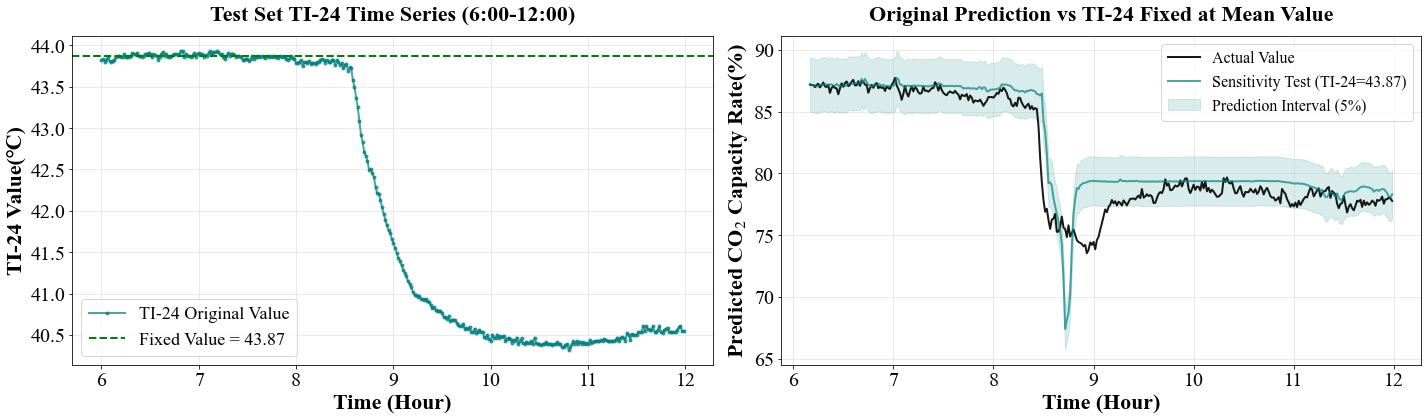

✓ TI-24 sensitivity-analysis comparison chart saved: sensitivity_analysis_TI24_comparison.png


In [74]:
# Step 5: Visual comparison (TI-24 time series + sensitivity prediction side-by-side)
print("\n" + "="*80)
print("Plot TI-24 sensitivity-analysis comparison")
print("="*80)

# time_windows_ti24 was created in previous cell

# Uncertainty interval (5%)
uncertainty_ratio = 0.025
ti24_sensitivity_pred_lower = y_pred_sensitivity_ti24 * (1 - uncertainty_ratio)
ti24_sensitivity_pred_upper = y_pred_sensitivity_ti24 * (1 + uncertainty_ratio)

# Create time axis (minutes)
time_minutes = np.arange(len(ti24_values))
time_hours = time_minutes / 60 + start_hour  # Convert to hours, starting at 6:00

# Create two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Left: TI-24 time series
ax_left = axes[0]
ax_left.plot(time_hours, ti24_values, 'o-', linewidth=2, markersize=3, alpha=0.7, color='teal', label='TI-24 Original Value')
ax_left.axhline(ti24_fixed_value, color='green', linestyle='--', linewidth=2, label=f'Fixed Value = {ti24_fixed_value:.2f}')
ax_left.set_xlabel('Time (Hour)', fontsize=22, fontweight='bold')
ax_left.set_ylabel('TI-24 Value(℃)', fontsize=22, fontweight='bold')
ax_left.set_title('Test Set TI-24 Time Series (6:00-12:00)', fontsize=22, fontweight='bold', pad=15)
ax_left.set_xticks(range(start_hour, end_hour + 1))
ax_left.tick_params(axis='both', labelsize=20)
ax_left.legend(fontsize=18, loc='best')
ax_left.grid(True, alpha=0.3)

# Right: original prediction vs sensitivity prediction
ax_right = axes[1]
ax_right.plot(time_windows_ti24, y_test_6_12_windows_ti24, '-', label='Actual Value', 
         linewidth=2, alpha=0.9, color='black')
ax_right.plot(time_windows_ti24, y_pred_sensitivity_ti24, '-', label=f'Sensitivity Test (TI-24={ti24_fixed_value:.2f})', 
         linewidth=2, markersize=3, alpha=0.7, color='teal')
ax_right.fill_between(time_windows_ti24, ti24_sensitivity_pred_lower, ti24_sensitivity_pred_upper, 
                 color='teal', alpha=0.15, label='Prediction Interval (5%)')
ax_right.set_xlabel('Time (Hour)', fontsize=22, fontweight='bold')
ax_right.set_ylabel('Predicted CO$_2$ Capacity Rate(%)', fontsize=22, fontweight='bold')
ax_right.set_title('Original Prediction vs TI-24 Fixed at Mean Value', fontsize=22, fontweight='bold', pad=15)
ax_right.set_xticks(range(start_hour, end_hour + 1))
ax_right.tick_params(axis='both', labelsize=20)
ax_right.legend(fontsize=16, loc='best')
ax_right.grid(True, alpha=0.3)
from matplotlib.ticker import FuncFormatter

ax_right.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'{y*100:.0f}')
)
plt.tight_layout()
plt.savefig('sensitivity_analysis_TI24_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"✓ TI-24 sensitivity-analysis comparison chart saved: sensitivity_analysis_TI24_comparison.png")

In [75]:
# Step 6: Compute TI-24 performance comparison
print("\n" + "="*80)
print("TI-24 performance comparison")
print("="*80)

# Original prediction metrics
r2_original_ti24 = r2_score(y_test_6_12_windows_ti24, y_pred_original_ti24)
rmse_original_ti24 = np.sqrt(mean_squared_error(y_test_6_12_windows_ti24, y_pred_original_ti24))
mae_original_ti24 = mean_absolute_error(y_test_6_12_windows_ti24, y_pred_original_ti24)

# TI-24 sensitivity-test metrics
r2_sensitivity_ti24 = r2_score(y_test_6_12_windows_ti24, y_pred_sensitivity_ti24)
rmse_sensitivity_ti24 = np.sqrt(mean_squared_error(y_test_6_12_windows_ti24, y_pred_sensitivity_ti24))
mae_sensitivity_ti24 = mean_absolute_error(y_test_6_12_windows_ti24, y_pred_sensitivity_ti24)

print(f"\n[Original Prediction Performance (TI-24 varying)]")
print(f"  • R²: {r2_original_ti24:.4f}")
print(f"  • RMSE: {rmse_original_ti24:.6f}")
print(f"  • MAE: {mae_original_ti24:.6f}")

print(f"\n[TI-24 Sensitivity-Test Performance (TI-24={ti24_fixed_value:.2f})]")
print(f"  • R²: {r2_sensitivity_ti24:.4f}")
print(f"  • RMSE: {rmse_sensitivity_ti24:.6f}")
print(f"  • MAE: {mae_sensitivity_ti24:.6f}")

print(f"\n[Performance Change]")
print(f"  • ΔR²: {r2_sensitivity_ti24 - r2_original_ti24:.4f} ({((r2_sensitivity_ti24 - r2_original_ti24) / r2_original_ti24 * 100):.2f}%)")
print(f"  • ΔRMSE: {rmse_sensitivity_ti24 - rmse_original_ti24:.6f} ({((rmse_sensitivity_ti24 - rmse_original_ti24) / rmse_original_ti24 * 100):.2f}%)")
print(f"  • ΔMAE: {mae_sensitivity_ti24 - mae_original_ti24:.6f} ({((mae_sensitivity_ti24 - mae_original_ti24) / mae_original_ti24 * 100):.2f}%)")


TI-24 performance comparison

[Original Prediction Performance (TI-24 varying)]
  • R²: 0.8452
  • RMSE: 0.017561
  • MAE: 0.011295

[TI-24 Sensitivity-Test Performance (TI-24=43.87)]
  • R²: 0.8450
  • RMSE: 0.017573
  • MAE: 0.011318

[Performance Change]
  • ΔR²: -0.0002 (-0.02%)
  • ΔRMSE: 0.000012 (0.07%)
  • ΔMAE: 0.000023 (0.20%)


In [76]:
# Compare sensitivity-analysis results of TI-34, TI-28, Level Reboiler, and TI-24
print("="*80)
print("Sensitivity Comparison: TI-34 vs TI-28 vs Level Reboiler vs TI-24")
print("="*80)

# Build comparison table with TI-24 added
comparison_df_ti24 = pd.DataFrame({
    'Metric': ['Mean', 'Std Dev', 'Min', 'Max', 'Coefficient of Variation (%)',
               'Avg Pred Difference', 'Avg Absolute Difference', 'Difference Std Dev',
               'Relative Impact (%)', 'ΔR²', 'ΔRMSE', 'ΔMAE', 'Sensitivity Rating'],
    'TI-34': [
        f"{ti34_mean:.6f}", f"{ti34_std:.6f}",
        f"{ti34_values.min():.6f}", f"{ti34_values.max():.6f}",
        f"{(ti34_std / ti34_mean * 100):.2f}",
        f"{pred_diff.mean():.6f}", f"{abs_pred_diff.mean():.6f}", f"{pred_diff.std():.6f}",
        f"{relative_impact:.2f}",
        f"{r2_sensitivity - r2_original:.4f}",
        f"{rmse_sensitivity - rmse_original:.6f}",
        f"{mae_sensitivity - mae_original:.6f}",
        'High' if relative_impact > 5 else 'Moderate' if relative_impact > 1 else 'Low'
    ],
    'TI-28': [
        f"{ti28_mean:.6f}", f"{ti28_std:.6f}",
        f"{ti28_values.min():.6f}", f"{ti28_values.max():.6f}",
        f"{(ti28_std / ti28_mean * 100):.2f}",
        f"{pred_diff_ti28.mean():.6f}", f"{abs_pred_diff_ti28.mean():.6f}", f"{pred_diff_ti28.std():.6f}",
        f"{relative_impact_ti28:.2f}",
        f"{r2_sensitivity_ti28 - r2_original:.4f}",
        f"{rmse_sensitivity_ti28 - rmse_original:.6f}",
        f"{mae_sensitivity_ti28 - mae_original:.6f}",
        'High' if relative_impact_ti28 > 5 else 'Moderate' if relative_impact_ti28 > 1 else 'Low'
    ],
    'Level Reboiler': [
        f"{level_reboiler_mean:.6f}", f"{level_reboiler_std:.6f}",
        f"{level_reboiler_values.min():.6f}", f"{level_reboiler_values.max():.6f}",
        f"{(level_reboiler_std / level_reboiler_mean * 100):.2f}",
        f"{pred_diff_lr.mean():.6f}", f"{abs_pred_diff_lr.mean():.6f}", f"{pred_diff_lr.std():.6f}",
        f"{relative_impact_lr:.2f}",
        f"{r2_sensitivity_lr - r2_original:.4f}",
        f"{rmse_sensitivity_lr - rmse_original:.6f}",
        f"{mae_sensitivity_lr - mae_original:.6f}",
        'High' if relative_impact_lr > 5 else 'Moderate' if relative_impact_lr > 1 else 'Low'
    ],
    'TI-24': [
        f"{ti24_mean:.6f}", f"{ti24_std:.6f}",
        f"{ti24_values.min():.6f}", f"{ti24_values.max():.6f}",
        f"{(ti24_std / ti24_mean * 100):.2f}",
        f"{pred_diff_ti24.mean():.6f}", f"{abs_pred_diff_ti24.mean():.6f}", f"{pred_diff_ti24.std():.6f}",
        f"{relative_impact_ti24:.2f}",
        f"{r2_sensitivity_ti24 - r2_original:.4f}",
        f"{rmse_sensitivity_ti24 - rmse_original:.6f}",
        f"{mae_sensitivity_ti24 - mae_original:.6f}",
        'High' if relative_impact_ti24 > 5 else 'Moderate' if relative_impact_ti24 > 1 else 'Low'
    ]
})

print("\n[Sensitivity Analysis Comparison Table (4 Features)]")
print(comparison_df_ti24.to_string(index=False))

# Save comparison result
comparison_df_ti24.to_csv('sensitivity_comparison_TI34_vs_TI28_vs_LevelReboiler_vs_TI24.csv',
                           index=False, encoding='utf-8-sig')
print(f"\n✓ Four-feature comparison saved: sensitivity_comparison_TI34_vs_TI28_vs_LevelReboiler_vs_TI24.csv")

# Identify most/least sensitive features
impacts_all = {
    'TI-34': relative_impact,
    'TI-28': relative_impact_ti28,
    'Level Reboiler': relative_impact_lr,
    'TI-24': relative_impact_ti24,
}
abs_diffs_all = {
    'TI-34': abs_pred_diff.mean(),
    'TI-28': abs_pred_diff_ti28.mean(),
    'Level Reboiler': abs_pred_diff_lr.mean(),
    'TI-24': abs_pred_diff_ti24.mean(),
}

most_sensitive = max(impacts_all, key=impacts_all.get)
least_sensitive = min(impacts_all, key=impacts_all.get)

print(f"\n[Sensitivity Ranking (4 Features)]")
sorted_impacts_all = sorted(impacts_all.items(), key=lambda x: x[1], reverse=True)
for rank, (feature, impact) in enumerate(sorted_impacts_all, 1):
    print(f"  {rank}. {feature}: {impact:.2f}% (Avg Abs Diff: {abs_diffs_all[feature]:.6f})")

print(f"\n[Conclusion]")
print(f"  • Most sensitive feature: {most_sensitive} (Relative impact: {impacts_all[most_sensitive]:.2f}%)")
print(f"  • Least sensitive feature: {least_sensitive} (Relative impact: {impacts_all[least_sensitive]:.2f}%)")
print(f"  • Recommendation: prioritize monitoring {most_sensitive} for CO2-capacity prediction stability")

Sensitivity Comparison: TI-34 vs TI-28 vs Level Reboiler vs TI-24

[Sensitivity Analysis Comparison Table (4 Features)]
                      Metric     TI-34     TI-28 Level Reboiler     TI-24
                        Mean 60.384742 89.986295      71.713622 42.121864
                     Std Dev  2.889625  0.547155       0.982941  1.592528
                         Min 56.710361 88.415932      70.477013 40.319363
                         Max 64.136719 91.900002      73.198975 43.936161
Coefficient of Variation (%)      4.79      0.61           1.37      3.78
         Avg Pred Difference  0.064069 -0.000252      -0.013956  0.000028
     Avg Absolute Difference  0.064538  0.005073       0.013956  0.000028
          Difference Std Dev  0.053768  0.013271       0.011935  0.000034
         Relative Impact (%)      7.86      0.62           1.70      0.00
                         ΔR²   -4.0536    0.0348        -0.0030   -0.0002
                       ΔRMSE  0.073994 -0.002099       0.000170  0

## Quantitative Analysis: Compare Sensitivity Effects of TI-34, TI-28, Level Reboiler, and TI-24 (8:00-12:00)

**Objective:**
- Focus on TI-34, TI-28, Level Reboiler, and TI-24
- Compare prediction behavior before and after sensitivity replacement
- Time range: 8:00-12:00 (4 hours)
- Main indicators: mean-level change metrics in this section

In [77]:
# Quantitative analysis: mean growth comparison for TI-34, TI-28, Level Reboiler, TI-24 in 8:00-12:00
print("="*100)
print("Quantitative analysis: sensitivity-prediction mean vs actual mean (8:00-12:00)")
print("="*100)

def calc_growth_8_12(feature_name, time_hours, y_actual, y_pred_original, y_pred_sensitivity, fixed_value=None):
    time_hours = np.asarray(time_hours).reshape(-1)
    y_actual = np.asarray(y_actual).reshape(-1)
    y_pred_original = np.asarray(y_pred_original).reshape(-1)
    y_pred_sensitivity = np.asarray(y_pred_sensitivity).reshape(-1)

    # Length alignment (use shortest length to avoid mask mismatch)
    min_len = min(len(time_hours), len(y_actual), len(y_pred_original), len(y_pred_sensitivity))
    if min_len <= 0:
        raise ValueError(f"{feature_name}: no valid data")

    time_hours = time_hours[:min_len]
    y_actual = y_actual[:min_len]
    y_pred_original = y_pred_original[:min_len]
    y_pred_sensitivity = y_pred_sensitivity[:min_len]

    mask = (time_hours >= 8) & (time_hours <= 12)
    if mask.sum() == 0:
        raise ValueError(f"{feature_name}: no samples in 8:00-12:00")

    actual_8_12 = y_actual[mask]
    pred_orig_8_12 = y_pred_original[mask]
    pred_sens_8_12 = y_pred_sensitivity[mask]
    t_8_12 = time_hours[mask]

    actual_mean = actual_8_12.mean()
    pred_orig_mean = pred_orig_8_12.mean()
    pred_sens_mean = pred_sens_8_12.mean()

    delta_sens_vs_actual = pred_sens_mean - actual_mean
    pct_sens_vs_actual = np.nan if actual_mean == 0 else (delta_sens_vs_actual / actual_mean) * 100

    delta_orig_vs_actual = pred_orig_mean - actual_mean
    pct_orig_vs_actual = np.nan if actual_mean == 0 else (delta_orig_vs_actual / actual_mean) * 100

    delta_sens_vs_orig = pred_sens_mean - pred_orig_mean
    pct_sens_vs_orig = np.nan if pred_orig_mean == 0 else (delta_sens_vs_orig / pred_orig_mean) * 100

    return {
        'Feature': feature_name,
        'Fixed value': fixed_value if fixed_value is not None else np.nan,
        'Aligned length': int(min_len),
        'Samples (8:00-12:00)': int(mask.sum()),
        'Time start': float(t_8_12.min()),
        'Time end': float(t_8_12.max()),
        'Actual mean': float(actual_mean),
        'Original prediction mean': float(pred_orig_mean),
        'Sensitivity prediction mean': float(pred_sens_mean),
        'Sensitivity-Actual (mean diff)': float(delta_sens_vs_actual),
        'Sensitivity growth vs Actual (%)': float(pct_sens_vs_actual),
        'Original growth vs Actual (%)': float(pct_orig_vs_actual),
        'Sensitivity growth vs Original (%)': float(pct_sens_vs_orig),
    }

growth_results = []

# 1) TI-34
growth_results.append(
    calc_growth_8_12(
        feature_name='TI-34',
        time_hours=time_windows,
        y_actual=y_test_6_12_windows,
        y_pred_original=y_pred_original,
        y_pred_sensitivity=y_pred_sensitivity,
        fixed_value=ti34_fixed_value if 'ti34_fixed_value' in globals() else None
    )
)

# 2) TI-28
growth_results.append(
    calc_growth_8_12(
        feature_name='TI-28',
        time_hours=time_windows_ti28 if 'time_windows_ti28' in globals() else time_windows,
        y_actual=y_test_6_12_windows_ti28 if 'y_test_6_12_windows_ti28' in globals() else y_test_6_12_windows,
        y_pred_original=y_pred_original_ti28 if 'y_pred_original_ti28' in globals() else y_pred_original,
        y_pred_sensitivity=y_pred_sensitivity_ti28 if 'y_pred_sensitivity_ti28' in globals() else y_pred_original,
        fixed_value=ti28_fixed_value if 'ti28_fixed_value' in globals() else None
    )
)

# 3) Level Reboiler
growth_results.append(
    calc_growth_8_12(
        feature_name='Level Reboiler',
        time_hours=time_windows_lr if 'time_windows_lr' in globals() else time_windows,
        y_actual=y_test_6_12_windows_lr if 'y_test_6_12_windows_lr' in globals() else y_test_6_12_windows,
        y_pred_original=y_pred_original_lr if 'y_pred_original_lr' in globals() else y_pred_original,
        y_pred_sensitivity=y_pred_sensitivity_lr if 'y_pred_sensitivity_lr' in globals() else y_pred_original,
        fixed_value=level_reboiler_fixed_value if 'level_reboiler_fixed_value' in globals() else None
    )
)

# 4) TI-24
growth_results.append(
    calc_growth_8_12(
        feature_name='TI-24',
        time_hours=time_windows_ti24 if 'time_windows_ti24' in globals() else time_windows,
        y_actual=y_test_6_12_windows_ti24 if 'y_test_6_12_windows_ti24' in globals() else y_test_6_12_windows,
        y_pred_original=y_pred_original_ti24 if 'y_pred_original_ti24' in globals() else y_pred_original,
        y_pred_sensitivity=y_pred_sensitivity_ti24 if 'y_pred_sensitivity_ti24' in globals() else y_pred_original,
        fixed_value=ti24_fixed_value if 'ti24_fixed_value' in globals() else None
    )
)

comparison_df_all = pd.DataFrame(growth_results)

print("\n[8:00-12:00 Mean-Growth Summary for Four Features]")
print(comparison_df_all.to_string(index=False))

print("\n[Key Conclusion: Sensitivity Prediction Mean vs Actual Mean]")
for _, row in comparison_df_all.iterrows():
    pct = row['Sensitivity growth vs Actual (%)']
    direction = 'increase' if pct >= 0 else 'decrease'
    print(f"  • {row['Feature']}: {direction} {abs(pct):.2f}%")

print("\n" + "="*100)
print("✅ Completed 8:00-12:00 mean-growth calculation for all four features")
print("="*100)

Quantitative analysis: sensitivity-prediction mean vs actual mean (8:00-12:00)

[8:00-12:00 Mean-Growth Summary for Four Features]
       Feature  Fixed value  Aligned length  Samples (8:00-12:00)  Time start  Time end  Actual mean  Original prediction mean  Sensitivity prediction mean  Sensitivity-Actual (mean diff)  Sensitivity growth vs Actual (%)  Original growth vs Actual (%)  Sensitivity growth vs Original (%)
         TI-34    63.861152             350                   240         8.0 11.983333     0.786745                  0.798107                     0.891622                        0.104877                         13.330496                       1.444146                           11.717137
         TI-28    89.676984             350                   240         8.0 11.983333     0.786745                  0.798107                     0.797717                        0.010972                          1.394634                       1.444146                           -0.048808
Le

In [78]:
# Save four-feature quantitative analysis results (mean-growth version)
print("\n" + "="*100)
print("Save four-feature quantitative analysis results (mean-growth version)")
print("="*100)

comparison_df_all.to_csv('quantitative_comparison_all_features_8_12.csv', index=False, encoding='utf-8-sig')
print("✓ Summary results saved: quantitative_comparison_all_features_8_12.csv")

report_lines = []
report_lines.append("="*100)
report_lines.append("8:00-12:00 Quantitative Analysis Report: comparison of sensitivity-prediction mean growth vs actual mean for four features")
report_lines.append("="*100)
report_lines.append("")
report_lines.append("Scope: mean and growth metrics only (no MAE/RMSE/R² error metrics in this section)")
report_lines.append("")

for _, row in comparison_df_all.iterrows():
    report_lines.append("-"*100)
    report_lines.append(f"Feature: {row['Feature']}")
    report_lines.append(f"  Fixed value: {row['Fixed value']:.6f}" if pd.notna(row['Fixed value']) else "  Fixed value: not provided")
    report_lines.append(f"  Samples (8:00-12:00): {int(row['Samples (8:00-12:00)'])}")
    report_lines.append(f"  Time range: {row['Time start']:.2f} - {row['Time end']:.2f} hours")
    report_lines.append(f"  Actual mean: {row['Actual mean']:.6f}")
    report_lines.append(f"  Original prediction mean: {row['Original prediction mean']:.6f}")
    report_lines.append(f"  Sensitivity prediction mean: {row['Sensitivity prediction mean']:.6f}")
    report_lines.append(f"  Sensitivity-Actual (mean diff): {row['Sensitivity-Actual (mean diff)']:+.6f}")
    report_lines.append(f"  Sensitivity growth vs Actual: {row['Sensitivity growth vs Actual (%)']:+.2f}%")
    report_lines.append(f"  Original growth vs Actual: {row['Original growth vs Actual (%)']:+.2f}%")
    report_lines.append(f"  Sensitivity growth vs Original: {row['Sensitivity growth vs Original (%)']:+.2f}%")

report_lines.append("")
report_lines.append("="*100)
report_lines.append(f"Generated at: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append("="*100)

quantitative_comparison_report = "\n".join(report_lines)
with open('quantitative_comparison_all_features_8_12_report.txt', 'w', encoding='utf-8') as f:
    f.write(quantitative_comparison_report)

print("✓ Summary report saved: quantitative_comparison_all_features_8_12_report.txt")
print("\n" + quantitative_comparison_report)


Save four-feature quantitative analysis results (mean-growth version)
✓ Summary results saved: quantitative_comparison_all_features_8_12.csv
✓ Summary report saved: quantitative_comparison_all_features_8_12_report.txt

8:00-12:00 Quantitative Analysis Report: comparison of sensitivity-prediction mean growth vs actual mean for four features

Scope: mean and growth metrics only (no MAE/RMSE/R² error metrics in this section)

----------------------------------------------------------------------------------------------------
Feature: TI-34
  Fixed value: 63.861152
  Samples (8:00-12:00): 240
  Time range: 8.00 - 11.98 hours
  Actual mean: 0.786745
  Original prediction mean: 0.798107
  Sensitivity prediction mean: 0.891622
  Sensitivity-Actual (mean diff): +0.104877
  Sensitivity growth vs Actual: +13.33%
  Original growth vs Actual: +1.44%
  Sensitivity growth vs Original: +11.72%
----------------------------------------------------------------------------------------------------
Featur


Plot mean-growth comparison for four features


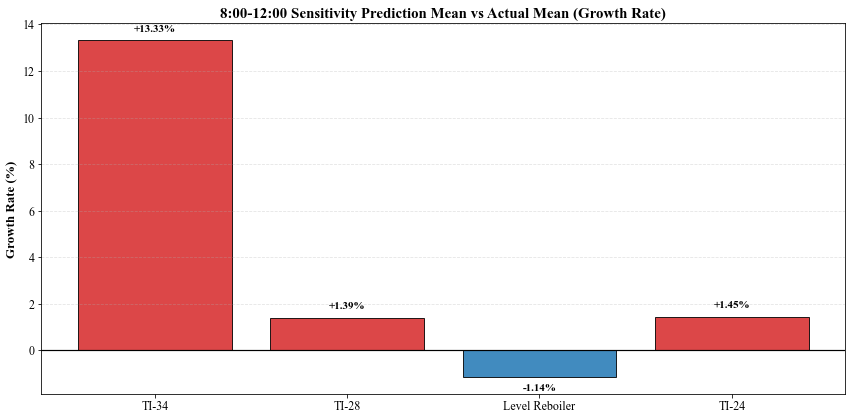

✓ Comparison figure saved: quantitative_comparison_all_features_8_12_growth.png

Generated files:
  1. quantitative_comparison_all_features_8_12.csv
  2. quantitative_comparison_all_features_8_12_report.txt
  3. quantitative_comparison_all_features_8_12_growth.png


In [79]:
# Visualization: sensitivity-prediction growth vs actual (%) for four features in 8:00-12:00
print("\n" + "="*100)
print("Plot mean-growth comparison for four features")
print("="*100)

plt.figure(figsize=(12, 6))

features = comparison_df_all['Feature'].tolist()
growth_pct = comparison_df_all['Sensitivity growth vs Actual (%)'].values
colors = ['#d62728' if x >= 0 else '#1f77b4' for x in growth_pct]

bars = plt.bar(features, growth_pct, color=colors, alpha=0.85, edgecolor='black', linewidth=1.0)
plt.axhline(0, color='black', linewidth=1.2)
plt.ylabel('Growth Rate (%)', fontsize=13, fontweight='bold')
plt.title('8:00-12:00 Sensitivity Prediction Mean vs Actual Mean (Growth Rate)', fontsize=15, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.35)

for b, v in zip(bars, growth_pct):
    y = v + (0.3 if v >= 0 else -0.3)
    va = 'bottom' if v >= 0 else 'top'
    plt.text(b.get_x() + b.get_width()/2, y, f"{v:+.2f}%", ha='center', va=va, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('quantitative_comparison_all_features_8_12_growth.png', dpi=200, bbox_inches='tight')
plt.show()

print("✓ Comparison figure saved: quantitative_comparison_all_features_8_12_growth.png")
print("\nGenerated files:")
print("  1. quantitative_comparison_all_features_8_12.csv")
print("  2. quantitative_comparison_all_features_8_12_report.txt")
print("  3. quantitative_comparison_all_features_8_12_growth.png")